# Hybrid TFT-MODFLOW -- Corrected Evaluation

Notebook copy of `_run_hybrid_tft.py` (the **complete hybrid** configuration: MODFLOW-derived features on) after fixing the evaluation-leakage bug found while preparing the reviewer rebuttal:

- The original "test" `TimeSeriesDataSet` spanned almost the entire dataset (train+val+test combined), not just the held-out test split, so the reported R² was mostly computed on windows the model had already been trained on.
- Fixed by tightening the val/test dataframe bounds and adding a post-hoc `filter_by_split` step that restricts scoring to genuinely held-out rows, plus de-duplicating a pytorch_forecasting boundary artifact that otherwise gives the single last day of each split ~46x the weight of every other day.
- Also adds Variable Selection Network (VSN) / attention interpretation extraction (`extract_and_save_interpretation`), and an `include_modflow_features` toggle used by the companion "TFT without MODFLOW" ablation notebook/script.
- **Under-dispersion fix (partial)**: the first corrected full run produced severely flat test predictions (std ≈0.09 vs. true std ≈0.33, R²=-0.397) because of a severe train/val/test distribution shift, a hardcoded `weight_decay=0.1` in the optimizer that silently ignored the config value, and `attention_head_size=24` not dividing `hidden_size=128` evenly. Fixed by wiring `weight_decay` through correctly and lowering `dropout`/`weight_decay`/`attention_head_size` (see the `## Run the pipeline` cell's inline note below).
- **Distribution-shift fix (the actual root cause)**: adding 90/180-day trend features on top of the above still made things *worse* on a real run (test R²=-6.17) -- the model was still being asked to output an absolute scaled water-level value far outside anything it saw in training (train scaled mean=0/std=1; test mean=1.90/std=0.33), which is exactly why trivial persistence/AR baselines score R²≈0.99 on this same period while the TFT struggled: they only ever predict a small change from a known anchor, never an absolute out-of-distribution value. Fixed by reparametrizing the TimeSeriesDataSet's target itself to `water_level[t] - water_level[t-1]` (`_add_lag_features`, `create_datasets`), with `reconstruct_absolute_from_delta` converting predictions back to absolute-level values post-hoc so every downstream metric/plot/saved file is unchanged in meaning.

**Run this with an environment that has `pytorch_forecasting` installed** (on this machine: `C:\Users\pctrema\anaconda3\python.exe`), and with the notebook's working directory set to the repo root (`code_version_2/code_version_2`) so the relative `data/`/`models/` paths resolve.

Same original hyperparameters as the paper's reported run (300 max epochs, patience 60, batch size 616) -- CPU-only on this machine, so this can take a long time to run end to end.


## Imports and reproducibility seed


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from typing import Dict, List, Tuple
import joblib

import torch
from torch. utils.data import DataLoader
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings('ignore')

# Windows consoles default to the cp1252 codepage, which can't encode the
# "✓"/"█"/"⚠" characters used in this file's progress prints. Force UTF-8
# stdout so the script runs the same everywhere, regardless of console
# codepage (see the same fix in feature_engineering.py / data_spliting_and_scalling.py).
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
    sys.stderr.reconfigure(encoding="utf-8")

def set_seed(seed:  int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


## 1. Hybrid configuration (`HybridTFTConfig`)


In [2]:
# =============================================================================
# 1. HYBRID CONFIGURATION
# =============================================================================
class HybridTFTConfig:
    def __init__(
        self,
        train_path: str,
        val_path: str,
        test_path: str,
        modflow_path: str,  # Path to MODFLOW predictions CSV
        scaler_path: str = None,
        model_dir: str = 'models/hybrid_tft',
        target_col: str = 'water_level',
        date_col: str = 'date',
        # MODFLOW column names (matching your CSV structure)
        modflow_date_col: str = 'date',
        modflow_pred_col: str = 'simulated_depth_ft',  # The MODFLOW prediction column
        # IMPROVED:  Even longer encoder for better long-term patterns
        max_encoder_length: int = 90,
        max_prediction_length: int = 1,
        hidden_size: int = 128,
        attention_head_size: int = 4,
        lstm_layers: int = 3,
        dropout: float = 0.4,
        hidden_continuous_size: int = 64,
        learning_rate: float = 0.0001,
        batch_size: int = 16,  # Smaller batch for better gradient estimates
        max_epochs: int = 300,
        patience: int = 60,  # Much more patience
        gradient_clip:  float = 0.1,
        # NEW: Weight decay for regularization
        weight_decay: float = 0.1,
        # Ablation switch: when False, MODFLOW-derived columns are computed
        # (harmless) but never promoted into time_varying_unknown_cols, so
        # the model trains as a standalone TFT with no physics prior input.
        include_modflow_features: bool = True,
        
        # IMPROVED:  Longer encoder for better context
        # max_encoder_length: int = 60,
        # max_prediction_length: int = 1,
        # hidden_size: int = 64,
        # attention_head_size: int = 4,
        # lstm_layers: int = 3,
        # dropout: float = 0.3,
        # hidden_continuous_size: int = 32,
        # learning_rate: float = 0.0003,
        # batch_size: int = 32,  # Smaller batch for better generalization
        # max_epochs: int = 200,
        # patience: int = 30,  # More patience
        # gradient_clip: float = 0.1,
    ):
        self.train_path = train_path
        self. val_path = val_path
        self.test_path = test_path
        self.modflow_path = modflow_path
        self.scaler_path = scaler_path
        self. model_dir = model_dir
        self.target_col = target_col
        self.date_col = date_col
        self.modflow_date_col = modflow_date_col
        self.modflow_pred_col = modflow_pred_col
        self.max_encoder_length = max_encoder_length
        self.max_prediction_length = max_prediction_length
        self.hidden_size = hidden_size
        self.attention_head_size = attention_head_size
        self.lstm_layers = lstm_layers
        self.dropout = dropout
        self.hidden_continuous_size = hidden_continuous_size
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.gradient_clip = gradient_clip
        self.weight_decay = weight_decay
        self.include_modflow_features = include_modflow_features
        self.use_gpu = torch.cuda.is_available()
        self.device = torch.device('cuda' if self.use_gpu else 'cpu')
        
        os.makedirs(model_dir, exist_ok=True)


## 2. Hybrid data preparation (`HybridDataPreparator`)

Loads train/val/test + MODFLOW predictions, interpolates MODFLOW to daily, scales it using train-only statistics, adds lag/date features, and builds the train/validation/test `TimeSeriesDataSet`s -- including the leakage fix in `create_datasets` (see the inline comments on `val_context_start` / `test_context_start`).


In [3]:
# =============================================================================
# 2. HYBRID DATA PREPARATION
# =============================================================================
class HybridDataPreparator:
    """
    Hybrid TFT-MODFLOW Data Preparator
    
    Key features:
    1. Loads MODFLOW monthly predictions and interpolates to daily
    2. Scales MODFLOW predictions to match the target variable scale
    3. Uses MODFLOW predictions as a key input feature (physics prior)
    4. Adds lag features and temporal features
    """
    
    def __init__(self, config: HybridTFTConfig):
        self.config = config
        self.train_df = None
        self.val_df = None
        self.test_df = None
        self. modflow_df = None
        self.full_df = None
        self. target_scaler = None
        self.time_varying_known_cols = []
        self.time_varying_unknown_cols = []
        self.train_cutoff = None
        self.val_cutoff = None
        
    def load_data(self):
        """Load all datasets including MODFLOW predictions."""
        print("=" * 70)
        print("     LOADING DATA (HYBRID)")
        print("=" * 70)
        
        # Load train/val/test data
        self. train_df = pd.read_csv(self.config.train_path)
        self.val_df = pd.read_csv(self.config.val_path)
        self.test_df = pd.read_csv(self. config.test_path)
        
        # Convert dates
        for df in [self.train_df, self.val_df, self. test_df]:
            if self.config.date_col in df.columns:
                df[self.config.date_col] = pd.to_datetime(df[self.config.date_col])
        
        print(f"\n  Train:  {len(self.train_df)} | Val: {len(self.val_df)} | Test: {len(self.test_df)}")
        
        # Load MODFLOW predictions
        if os.path.exists(self.config.modflow_path):
            self.modflow_df = pd.read_csv(self.config.modflow_path)
            if self.config.modflow_date_col in self.modflow_df.columns:
                self. modflow_df[self.config.modflow_date_col] = pd.to_datetime(
                    self.modflow_df[self.config.modflow_date_col]
                )
            print(f"  ✓ Loaded MODFLOW predictions: {len(self.modflow_df)} records")
            print(f"    Columns: {list(self.modflow_df. columns)}")
        else:
            print(f"  ⚠ MODFLOW file not found: {self.config. modflow_path}")
            self.modflow_df = None
        
        # Load scalers
        if self.config.scaler_path and os.path.exists(self. config.scaler_path):
            scalers = joblib.load(self.config.scaler_path)
            self.target_scaler = scalers. get('target_scaler')
            print("  ✓ Loaded scalers")
        
        self._check_distribution()
        
        return self.train_df, self. val_df, self.test_df
    
    def _check_distribution(self):
        """Check distribution shift between splits."""
        target = self.config.target_col
        
        train_mean = self.train_df[target].mean()
        train_std = self.train_df[target].std()
        val_mean = self.val_df[target].mean()
        test_mean = self.test_df[target].mean()
        
        print(f"\n  Distribution Check:")
        print(f"    Train:  mean={train_mean:.4f}, std={train_std:.4f}")
        print(f"    Val:    mean={val_mean:.4f}")
        print(f"    Test:  mean={test_mean:.4f}")
        
        if abs(test_mean - train_mean) > 1.5 * train_std:
            print(f"\n  ⚠ WARNING:  Significant distribution shift detected!")
            print(f"    MODFLOW physics prior will help the model adapt.")
    
    def _interpolate_modflow_to_daily(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Interpolate monthly MODFLOW predictions to daily resolution. 
        This is critical for the hybrid approach as MODFLOW outputs monthly data.
        """
        if self.modflow_df is None:
            return df
        
        print("\n  Interpolating MODFLOW predictions to daily resolution...")
        
        # Get the MODFLOW prediction column
        modflow_col = self.config.modflow_pred_col
        date_col = self.config.modflow_date_col
        
        if modflow_col not in self.modflow_df.columns:
            # Try to find a suitable column
            potential_cols = ['simulated_depth_ft', 'modflow_prediction', 'predicted', 'simulated']
            for col in potential_cols:
                if col in self. modflow_df.columns:
                    modflow_col = col
                    break
            else:
                print(f"    ⚠ Could not find MODFLOW prediction column.  Available:  {list(self.modflow_df.columns)}")
                return df
        
        print(f"    Using MODFLOW column: {modflow_col}")
        
        # Create a copy of MODFLOW data with only needed columns
        modflow_subset = self.modflow_df[[date_col, modflow_col]].copy()
        modflow_subset = modflow_subset.rename(columns={
            date_col: 'date',
            modflow_col: 'modflow_prediction'
        })
        
        # Create daily date range
        date_min = df[self.config.date_col].min()
        date_max = df[self.config.date_col].max()
        daily_dates = pd.date_range(start=date_min, end=date_max, freq='D')
        
        # Create daily dataframe
        daily_df = pd.DataFrame({'date': daily_dates})
        
        # Merge MODFLOW monthly predictions
        daily_df = daily_df.merge(modflow_subset, on='date', how='left')
        
        # Interpolate to fill daily values
        daily_df['modflow_prediction'] = daily_df['modflow_prediction'].interpolate(
            method='linear', 
            limit_direction='both'
        )
        
        # Forward/backward fill any remaining NaN
        daily_df['modflow_prediction'] = daily_df['modflow_prediction'].ffill().bfill()
        
        # Merge with main dataframe
        df = df.merge(daily_df, left_on=self.config.date_col, right_on='date', how='left')
        
        # Handle potential duplicate date column
        if 'date_x' in df.columns:
            df = df.drop(columns=['date_y'])
            df = df.rename(columns={'date_x': self.config.date_col})
        elif 'date' in df.columns and self.config.date_col != 'date':
            df = df.drop(columns=['date'])
        
        # Fill any remaining NaN in modflow_prediction
        if 'modflow_prediction' in df.columns:
            df['modflow_prediction'] = df['modflow_prediction'].interpolate(
                method='linear', limit_direction='both'
            ).ffill().bfill()
            
            # If still NaN (edge case), use target mean
            if df['modflow_prediction'].isna().any():
                df['modflow_prediction'] = df['modflow_prediction'].fillna(
                    df[self.config.target_col].mean()
                )
        
        print(f"    ✓ MODFLOW predictions merged:  {df['modflow_prediction'].notna().sum()} records")
        
        return df
    
    def _scale_modflow_predictions(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Scale MODFLOW predictions to match the target variable scale.
        This is important because MODFLOW outputs are in different units/scale.

        LEAKAGE FIX: the scaling statistics (mean/std of target and of the
        MODFLOW prediction) are computed from the TRAIN split only. Using
        df[target].mean()/.std() over the full (train+val+test) frame would
        let validation/test-period statistics leak into a transform that is
        then applied to the training data itself.
        """
        if 'modflow_prediction' not in df.columns:
            return df
        
        print("\n  Scaling MODFLOW predictions to match target scale...")
        
        target = self.config.target_col
        modflow = 'modflow_prediction'
        
        # Calculate scaling parameters from the TRAIN split only
        if 'split' in df.columns and (df['split'] == 'train').any():
            train_mask = df['split'] == 'train'
        else:
            # Fallback (should not happen in prepare_for_tft's call order)
            train_mask = pd.Series(True, index=df.index)
        
        target_mean = df.loc[train_mask, target].mean()
        target_std = df.loc[train_mask, target].std()
        modflow_mean = df.loc[train_mask, modflow].mean()
        modflow_std = df.loc[train_mask, modflow].std()
        
        # Z-score normalize (using train stats) then rescale to match target distribution
        if modflow_std > 0:
            df['modflow_scaled'] = (df[modflow] - modflow_mean) / modflow_std
            df['modflow_scaled'] = df['modflow_scaled'] * target_std + target_mean
        else:
            df['modflow_scaled'] = df[modflow]
        
        print(f"    Target (train-only):  mean={target_mean:.4f}, std={target_std:.4f}")
        print(f"    MODFLOW (train-only, original): mean={modflow_mean:.4f}, std={modflow_std:.4f}")
        print(f"    MODFLOW (scaled): mean={df['modflow_scaled'].mean():.4f}, std={df['modflow_scaled'].std():.4f}")
        
        return df
    
    def prepare_for_tft(self):
        """Prepare hybrid data with MODFLOW predictions and feature engineering."""
        print("\n" + "=" * 70)
        print("     PREPARING DATA FOR HYBRID TFT")
        print("=" * 70)
        
        if self.train_df is None: 
            self.load_data()
        
        # Add split labels
        self.train_df = self.train_df.copy()
        self.val_df = self.val_df.copy()
        self.test_df = self.test_df.copy()
        
        self.train_df['split'] = 'train'
        self.val_df['split'] = 'val'
        self.test_df['split'] = 'test'
        
        # Combine and sort
        self.full_df = pd.concat([self.train_df, self.val_df, self.test_df], ignore_index=True)
        
        if self.config.date_col in self.full_df.columns:
            self.full_df = self.full_df.sort_values(self.config.date_col).reset_index(drop=True)
        
        # Add time index and group
        self.full_df['time_idx'] = np.arange(len(self. full_df))
        self.full_df['group_id'] = 'well_1'
        
        # Store cutoff indices
        self.train_cutoff = self.full_df[self.full_df['split'] == 'train']['time_idx'].max()
        self.val_cutoff = self.full_df[self.full_df['split'] == 'val']['time_idx'].max()
        
        # CRITICAL: Merge MODFLOW predictions (physics prior)
        self.full_df = self._interpolate_modflow_to_daily(self.full_df)
        
        # Scale MODFLOW predictions to match target (train-split statistics only)
        self.full_df = self._scale_modflow_predictions(self.full_df)
        
        # Add lag features
        self._add_lag_features()
        
        # Add date features
        self._add_date_features()
        
        # Identify features (including MODFLOW as key feature)
        self._identify_features()
        
        # Clean data
        self._clean_data()
        
        print(f"\n  Total records: {len(self.full_df)}")
        print(f"  Train cutoff idx: {self.train_cutoff}")
        print(f"  Val cutoff idx: {self. val_cutoff}")
        
        return self.full_df
    
    def _add_lag_features(self):
        """
        Add lag features including MODFLOW-based features.

        LEAKAGE FIX: the target's rolling mean and first difference used to
        be computed directly on self.full_df[target], so at row t they
        included water_level[t] itself (pandas .rolling(min_periods=1) and
        .diff() both incorporate the current row). Since this is a 1-day
        forecast horizon, that is the target leaking into its own feature.
        Both are now computed on the lag-1 series, so at row t they only
        encode information available through t-1.
        The MODFLOW-target residual is still computed contemporaneously
        (it needs today's observation to know today's MODFLOW error), but
        only its lag-1 version (modflow_residual_lag_1) is ever exposed as
        a model feature -- see _identify_features, where the raw
        'modflow_residual' column is explicitly excluded.
        """
        print("\n  Adding lag features...")
        target = self.config.target_col

        # DELTA-TARGET REPARAMETRIZATION: the model is trained to predict
        # water_level[t] - water_level[t-1] (this column), not the absolute
        # level. See create_datasets() for where this becomes the
        # TimeSeriesDataSet target, and reconstruct_absolute_from_delta()
        # (module-level function) for how it's converted back to an
        # absolute-level prediction at evaluation time.
        #
        # Why: train/val/test have a severe distribution shift in the
        # ABSOLUTE level (train scaled mean=0/std=1; val mean=1.80; test
        # mean=1.90, both std~0.33 -- printed by _check_distribution). A
        # model predicting the absolute level has to extrapolate into
        # scaled-value territory it essentially never saw during training,
        # and in practice collapsed to a narrow, badly-offset band (test
        # R2 as low as -6 in one run). The day-over-day CHANGE, by
        # contrast, is far more stationary across the whole record (this
        # is exactly why the trivial persistence/AR baselines in
        # baseline_forecasts.py score R2~0.99 on this same test period --
        # they only ever have to predict a small delta from a known
        # anchor). Reframing the learning target the same way lets the
        # network reuse that same persistence structure instead of fighting
        # the level shift, while still adding a learned correction on top.
        # water_level[t] - water_level[t-1] is well-defined and uses only
        # today's and yesterday's true values -- no different in kind from
        # any other one-step forecast target.
        self.full_df[f'{target}_target_delta'] = self.full_df[target] - self.full_df[target].shift(1)

        # Target lags (already strictly historical: shift(lag), lag >= 1)
        for lag in [1, 7, 14]:
            self.full_df[f'{target}_lag_{lag}'] = self.full_df[target]. shift(lag)
        
        # Rolling statistics - computed on the lag-1 series so the window
        # at row t covers [t-window, t-1], never t itself
        target_shifted = self.full_df[target].shift(1)
        for window in [7, 14, 90, 180]:
            self.full_df[f'{target}_rmean_{window}'] = (
                target_shifted.rolling(window=window, min_periods=1).mean()
            )

        # Longer-range momentum (t-1 vs ~6 months earlier, strictly
        # historical). The 7/14-day windows above only see local noise;
        # this multi-year record has a slow, multi-month rise/decline (see
        # the train/val/test distribution-shift warning in
        # _check_distribution), so the model needs a feature that actually
        # spans that timescale to have any chance of extrapolating the
        # trend into val/test rather than regressing to the training mean.
        self.full_df[f'{target}_trend_180'] = target_shifted.diff(180)

        # First difference (t-1 vs t-2, strictly historical)
        self.full_df[f'{target}_diff'] = target_shifted.diff(1)
        
        # MODFLOW-specific features (if available)
        if 'modflow_scaled' in self.full_df. columns:
            # MODFLOW lags
            for lag in [1, 7]: 
                self.full_df[f'modflow_lag_{lag}'] = self.full_df['modflow_scaled'].shift(lag)
            
            # MODFLOW rolling mean
            self.full_df['modflow_rmean_7'] = (
                self.full_df['modflow_scaled'].rolling(window=7, min_periods=1).mean()
            )
            
            # MODFLOW-target residual (TFT learns to correct MODFLOW errors).
            # Computed contemporaneously (needs today's target) - NOT used
            # directly as a feature, see exclude set in _identify_features.
            self.full_df['modflow_residual'] = self.full_df[target] - self.full_df['modflow_scaled']
            
            # Lagged residual (helps model learn error patterns) - this is
            # the only residual-derived column ever used as a model input,
            # and it only carries information through t-1.
            self.full_df['modflow_residual_lag_1'] = self.full_df['modflow_residual'].shift(1)
        
        print(f"    Added target lags and rolling stats")
        if 'modflow_scaled' in self.full_df.columns:
            print(f"    Added MODFLOW features (key physics prior)")
    
    def _add_date_features(self):
        """Add cyclical date features."""
        if self.config.date_col in self.full_df.columns:
            dates = pd.to_datetime(self.full_df[self.config.date_col])
            
            self.full_df['month_sin'] = np.sin(2 * np.pi * dates.dt.month / 12)
            self.full_df['month_cos'] = np.cos(2 * np.pi * dates.dt. month / 12)
            self.full_df['doy_sin'] = np.sin(2 * np.pi * dates. dt.dayofyear / 365)
            self.full_df['doy_cos'] = np.cos(2 * np.pi * dates.dt.dayofyear / 365)
    
    def _identify_features(self):
        """
        Identify feature types with MODFLOW as key feature.

        NOTE ON LEAKAGE: 'modflow_prediction' (unscaled) and 'modflow_residual'
        (the contemporaneous, un-lagged residual = target - modflow_scaled)
        are deliberately kept in `exclude` and never enter
        time_varying_unknown_cols. Only their lag-safe counterparts
        ('modflow_scaled' and 'modflow_residual_lag_1') are used as inputs.
        time_varying_unknown_cols (plus the target) are only ever sampled
        by TimeSeriesDataSet from encoder (historical) positions, never at
        the decoder/forecast-origin time step, so even the target column
        itself does not leak into its own 1-day-ahead prediction.
        """
        print("\n  Identifying features...")
        
        exclude = {self.config.date_col, 'time_idx', 'group_id', 'split',
                   self.config.target_col, 'Unnamed: 0', 'index',
                   'modflow_prediction', 'modflow_residual',
                   # This IS the TimeSeriesDataSet target now (see
                   # create_datasets) -- must never also be treated as an
                   # ordinary auxiliary input feature, or the model could
                   # trivially "predict" its own target from itself.
                   f'{self.config.target_col}_target_delta'}
        
        # Known features (calendar - known in future)
        self.time_varying_known_cols = ['month_sin', 'month_cos', 'doy_sin', 'doy_cos']
        self.time_varying_known_cols = [c for c in self.time_varying_known_cols 
                                        if c in self.full_df.columns]
        
        # Unknown features - MODFLOW as priority (key physics feature)
        target = self.config.target_col
        modflow_features = [
            # MODFLOW features (CRITICAL - physics prior)
            'modflow_scaled',  # Main MODFLOW prediction
            'modflow_lag_1', 'modflow_lag_7',
            'modflow_rmean_7',
            'modflow_residual_lag_1',  # Helps learn error patterns
        ] if self.config.include_modflow_features else []
        priority_features = [
            *modflow_features,
            # Target lag features
            f'{target}_lag_1', f'{target}_lag_7', f'{target}_lag_14',
            f'{target}_rmean_7', f'{target}_rmean_14', f'{target}_diff',
            # Long-range trend features -- give the model a chance to track
            # the multi-month drift that separates train from val/test,
            # instead of only ever seeing 7/14-day local windows.
            f'{target}_rmean_90', f'{target}_rmean_180', f'{target}_trend_180',
            # Climate features (if available)
            'total_precipitation_sum', 'evaporation_sum',
            '2m_temperature_mean', 'surface_pressure_mean',
        ]

        numeric_cols = self.full_df.select_dtypes(include=[np.number]).columns. tolist()
        self.time_varying_unknown_cols = [c for c in priority_features
                                          if c in numeric_cols and c not in exclude]

        # Limit features
        max_features = 20
        self.time_varying_unknown_cols = self.time_varying_unknown_cols[:max_features]
        
        print(f"    Known features: {len(self.time_varying_known_cols)}")
        print(f"    Unknown features: {len(self.time_varying_unknown_cols)}")
        print(f"    Feature list:")
        for c in self.time_varying_unknown_cols:
            print(f"      - {c}")
    
    def _clean_data(self):
        """Clean numeric data."""
        all_cols = (self.time_varying_known_cols +
                   self.time_varying_unknown_cols +
                   [self.config.target_col, f'{self.config.target_col}_target_delta'])
        
        for col in all_cols:
            if col in self.full_df.columns:
                self.full_df[col] = pd.to_numeric(self.full_df[col], errors='coerce')
                self.full_df[col] = self.full_df[col]. replace([np.inf, -np.inf], np.nan)
                self.full_df[col] = self.full_df[col].interpolate(method='linear', limit_direction='both')
                self.full_df[col] = self.full_df[col].ffill().bfill().fillna(0)
    
    def create_datasets(self):
        """Create TFT datasets."""
        print("\n" + "=" * 70)
        print("     CREATING DATASETS (HYBRID)")
        print("=" * 70)
        
        if self.full_df is None:
            self.prepare_for_tft()
        
        cfg = self.config
        
        # Skip rows with NaN lags
        min_valid_idx = max(cfg.max_encoder_length, 14)
        
        print(f"\n  Encoder length: {cfg.max_encoder_length}")
        print(f"  Prediction length: {cfg.max_prediction_length}")
        print(f"  Min valid idx: {min_valid_idx}")
        print(f"  Train cutoff: {self.train_cutoff}")
        print(f"  Val cutoff: {self.val_cutoff}")
        
        # Training data
        train_data = self. full_df[
            (self.full_df['time_idx'] >= min_valid_idx) & 
            (self.full_df['time_idx'] <= self.train_cutoff - cfg.max_prediction_length)
        ].copy()
        
        print(f"\n  Training data points: {len(train_data)}")
        
        if len(train_data) < cfg.max_encoder_length + 10:
            print("  ⚠ Not enough training data!  Adjusting encoder length...")
            cfg.max_encoder_length = max(10, len(train_data) // 3)
            print(f"  New encoder length: {cfg.max_encoder_length}")
        
        # Create training TimeSeriesDataSet
        # DELTA-TARGET REPARAMETRIZATION: target is water_level's
        # day-over-day change, not its absolute level -- see the comment in
        # _add_lag_features for why. The raw target_col's own lags (e.g.
        # water_level_lag_1) are still available via time_varying_unknown_cols
        # as auxiliary context; only the *target* of the TimeSeriesDataSet
        # changes here.
        delta_target_col = f'{cfg.target_col}_target_delta'
        training = TimeSeriesDataSet(
            train_data,
            time_idx='time_idx',
            target=delta_target_col,
            group_ids=['group_id'],
            min_encoder_length=cfg.max_encoder_length // 2,
            max_encoder_length=cfg.max_encoder_length,
            min_prediction_length=1,
            max_prediction_length=cfg.max_prediction_length,
            static_categoricals=['group_id'],
            time_varying_known_reals=self.time_varying_known_cols,
            time_varying_unknown_reals=self.time_varying_unknown_cols + [delta_target_col],
            target_normalizer=None,
            add_relative_time_idx=True,
            add_target_scales=True,
            add_encoder_length=True,
            allow_missing_timesteps=True,
        )
        
        print(f"\n  Training dataset samples: {len(training)}")
        
        # Validation data
        # LEAKAGE FIX: this frame is only meant to supply enough pre-val
        # history for encoder context on the earliest val rows. It used to
        # start at min_valid_idx (near the very start of train), which let
        # TimeSeriesDataSet.from_dataset(..., predict=False, ...) build
        # scorable prediction windows out of almost the entire train split
        # -- i.e. "validation" metrics were mostly computed on
        # already-trained-on windows. Starting the frame at
        # train_cutoff - max_encoder_length + 1 keeps exactly the history
        # needed and nothing more; scoring is still restricted to true val
        # rows afterward via the time_idx -> split filter in
        # run_hybrid_tft_modflow_pipeline.
        val_context_start = max(min_valid_idx, self.train_cutoff - cfg.max_encoder_length + 1)
        train_val_data = self.full_df[
            (self.full_df['time_idx'] >= val_context_start) &
            (self.full_df['time_idx'] <= self.val_cutoff)
        ].copy()

        validation = TimeSeriesDataSet. from_dataset(
            training,
            train_val_data,
            predict=False,
            stop_randomization=True,
        )

        print(f"  Validation dataset samples: {len(validation)}")

        # Test data
        # Same fix as validation above: only keep enough pre-test history
        # for encoder context, not the whole train+val range.
        test_context_start = max(min_valid_idx, self.val_cutoff - cfg.max_encoder_length + 1)
        all_valid_data = self.full_df[self.full_df['time_idx'] >= test_context_start].copy()

        testing = TimeSeriesDataSet.from_dataset(
            training,
            all_valid_data,
            predict=False,
            stop_randomization=True,
        )

        print(f"  Test dataset samples: {len(testing)}")
        
        # Dataloaders
        train_loader = training.to_dataloader(
            train=True, 
            batch_size=cfg. batch_size, 
            num_workers=0,
            shuffle=True
        )
        val_loader = validation.to_dataloader(
            train=False, 
            batch_size=cfg.batch_size * 2, 
            num_workers=0
        )
        test_loader = testing.to_dataloader(
            train=False, 
            batch_size=cfg.batch_size * 2, 
            num_workers=0
        )
        
        print(f"\n  Train batches: {len(train_loader)}")
        print(f"  Val batches: {len(val_loader)}")
        print(f"  Test batches:  {len(test_loader)}")
        
        return training, validation, testing, train_loader, val_loader, test_loader
    
    def inverse_transform(self, scaled_values):
        """Inverse transform predictions."""
        if self.target_scaler is not None:
            if len(scaled_values. shape) == 1:
                scaled_values = scaled_values. reshape(-1, 1)
            return self.target_scaler.inverse_transform(scaled_values).flatten()
        return scaled_values


## 3. Training utilities (header + prediction-tensor helper)


In [4]:
# =============================================================================
# 3. TRAINING
# =============================================================================
def get_prediction_tensor(output):
    """Extract prediction tensor from TFT output."""
    if isinstance(output, dict):
        return output['prediction']
    if hasattr(output, 'prediction'):
        return output.prediction
    if isinstance(output, torch.Tensor):
        return output
    return output


## Training loop (`train_hybrid_tft`)


In [5]:
def train_hybrid_tft(
    model: TemporalFusionTransformer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config,  # HybridTFTConfig
) -> Tuple[TemporalFusionTransformer, List[float], List[float]]:
    """
    Improved training loop for hybrid TFT-MODFLOW model.
    
    Key improvements:
    1. Better regularization with label smoothing and mixup-style augmentation
    2. Warmup learning rate schedule
    3. Gradient accumulation for effective larger batch sizes
    4. Multiple loss functions combined
    5. Better early stopping with minimum epochs
    """
    print("\n" + "=" * 70)
    print("     TRAINING HYBRID TFT-MODFLOW MODEL (IMPROVED)")
    print("=" * 70)
    
    device = config.device
    model = model.to(device)
    
    # Optimizer with different learning rates for different parameter groups
    # Lower LR for pretrained-style layers, higher for task-specific
    optimizer = torch.optim. AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
        betas=(0.9, 0.999),
        eps=1e-8,
    )
    
    # Warmup + Cosine Annealing scheduler
    warmup_epochs = min(10, config.max_epochs // 10)
    
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # Linear warmup
            return (epoch + 1) / warmup_epochs
        else:
            # Cosine annealing
            progress = (epoch - warmup_epochs) / (config.max_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # Multiple loss functions
    mse_loss = torch.nn.MSELoss()
    mae_loss = torch.nn.L1Loss()
    huber_loss = torch.nn. SmoothL1Loss(beta=0.5)  # Robust to outliers
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    # Minimum epochs before early stopping can trigger
    min_epochs = max(20, config.max_epochs // 5)
    
    # Gradient accumulation steps (effective batch size = batch_size * accumulation_steps)
    accumulation_steps = 2
    
    print(f"\n  Device: {device}")
    print(f"  Max epochs: {config.max_epochs}")
    print(f"  Min epochs before early stopping: {min_epochs}")
    print(f"  Patience:  {config.patience}")
    print(f"  Learning rate: {config.learning_rate}")
    print(f"  Warmup epochs: {warmup_epochs}")
    print(f"  Gradient accumulation steps: {accumulation_steps}")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    
    for epoch in range(config.max_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        n_train = 0
        
        optimizer.zero_grad()
        
        for batch_idx, batch in enumerate(train_loader):
            x, y = batch
            
            x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
            
            if isinstance(y, (tuple, list)):
                target = y[0]. to(device)
            else:
                target = y.to(device)
            
            # Forward pass
            output = model(x)
            prediction = get_prediction_tensor(output)
            
            if not isinstance(prediction, torch.Tensor):
                continue
            
            # Extract median prediction
            if len(prediction.shape) == 3:
                pred_median = prediction[: , : , prediction.shape[2] // 2]
            else:
                pred_median = prediction
            
            # Handle shape mismatch
            if pred_median.shape != target.shape:
                if len(pred_median.shape) == 2 and len(target.shape) == 2:
                    min_len = min(pred_median.shape[1], target.shape[1])
                    pred_median = pred_median[:, :min_len]
                    target = target[:, :min_len]
            
            # Combined loss with emphasis on robustness
            # MSE for accuracy, MAE for robustness, Huber for balance
            loss_mse = mse_loss(pred_median, target)
            loss_mae = mae_loss(pred_median, target)
            loss_huber = huber_loss(pred_median, target)
            
            # Weighted combination - emphasize Huber for robustness
            loss = 0.3 * loss_mse + 0.3 * loss_mae + 0.4 * loss_huber
            
            # Add temporal consistency regularization
            if pred_median.shape[0] > 1:
                # Penalize large differences between consecutive predictions
                pred_diff = torch.diff(pred_median, dim=0)
                target_diff = torch.diff(target, dim=0)
                consistency_loss = mae_loss(pred_diff, target_diff)
                loss = loss + 0.1 * consistency_loss
            
            # Scale loss for gradient accumulation
            loss = loss / accumulation_steps
            loss.backward()
            
            # Gradient accumulation
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
                optimizer.step()
                optimizer.zero_grad()
            
            epoch_train_loss += loss.item() * accumulation_steps
            n_train += 1
        
        scheduler.step()
        
        avg_train_loss = epoch_train_loss / max(n_train, 1)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        epoch_val_loss = 0
        n_val = 0
        val_predictions = []
        val_targets = []
        
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch
                
                x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
                
                if isinstance(y, (tuple, list)):
                    target = y[0].to(device)
                else: 
                    target = y.to(device)
                
                output = model(x)
                prediction = get_prediction_tensor(output)
                
                if not isinstance(prediction, torch.Tensor):
                    continue
                
                if len(prediction.shape) == 3:
                    pred_median = prediction[:, :, prediction. shape[2] // 2]
                else:
                    pred_median = prediction
                
                if pred_median.shape != target.shape:
                    if len(pred_median.shape) == 2 and len(target. shape) == 2:
                        min_len = min(pred_median.shape[1], target.shape[1])
                        pred_median = pred_median[: , :min_len]
                        target = target[:, :min_len]
                
                # Use same combined loss for validation
                loss_mse = mse_loss(pred_median, target)
                loss_mae = mae_loss(pred_median, target)
                loss_huber = huber_loss(pred_median, target)
                loss = 0.3 * loss_mse + 0.3 * loss_mae + 0.4 * loss_huber
                
                epoch_val_loss += loss.item()
                n_val += 1
                
                val_predictions. append(pred_median.cpu())
                val_targets.append(target.cpu())
        
        avg_val_loss = epoch_val_loss / max(n_val, 1)
        val_losses.append(avg_val_loss)
        
        # Calculate additional metrics for monitoring
        if val_predictions:
            all_preds = torch.cat(val_predictions, dim=0).numpy().flatten()
            all_targets = torch.cat(val_targets, dim=0).numpy().flatten()
            val_rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
        else:
            val_rmse = float('inf')
        
        # Current learning rate
        current_lr = scheduler.get_last_lr()[0]
        
        # Logging
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{config.max_epochs}:   "
                  f"Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}, "
                  f"Val_RMSE={val_rmse:.4f}, LR={current_lr:.6f}")
        
        # Early stopping logic (only after min_epochs)
        if epoch >= min_epochs - 1:
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                print(f"  Epoch {epoch+1:3d}:  ✓ New best = {avg_val_loss:.4f} (RMSE={val_rmse:.4f})")
            else:
                patience_counter += 1
                if patience_counter >= config.patience:
                    print(f"\n  Early stopping at epoch {epoch+1}")
                    break
        elif avg_val_loss < best_val_loss:
            # Still track best model during warmup period
            best_val_loss = avg_val_loss
            best_state = {k: v. cpu().clone() for k, v in model.state_dict().items()}
            print(f"  Epoch {epoch+1:3d}:  ✓ New best = {avg_val_loss:.4f} (warmup)")
    
    # Load best model
    if best_state: 
        model.load_state_dict(best_state)
        model = model.to(device)
    
    # Save model
    model_path = os.path.join(config.model_dir, 'hybrid_tft_modflow.pt')
    torch.save(model.state_dict(), model_path)
    print(f"\n  Best model saved:  {model_path}")
    print(f"  Best validation loss: {best_val_loss:.4f}")
    
    return model, train_losses, val_losses


## Prediction (`predict_tft`)


In [6]:
def predict_tft(model, data_loader, device, return_uncertainty=False):
    """
    Make predictions with TFT. 
    
    Improvements:
    1. Option to return uncertainty estimates
    2. Better handling of quantile predictions
    3. More robust index tracking
    """
    model.eval()
    
    all_predictions = []
    all_actuals = []
    all_indices = []
    all_lower = []  # Lower quantile
    all_upper = []  # Upper quantile
    
    with torch.no_grad():
        for batch in data_loader: 
            x, y = batch
            x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
            
            if isinstance(y, (tuple, list)):
                target = y[0].cpu().numpy()
            else:
                target = y.cpu().numpy()
            
            output = model(x)
            prediction = get_prediction_tensor(output)
            
            if isinstance(prediction, torch.Tensor):
                predictions = prediction.cpu().numpy()
            else:
                continue
            
            # Extract indices
            if 'decoder_time_idx' in x:
                indices = x['decoder_time_idx'][: , 0]. cpu().numpy().tolist()
            else:
                indices = list(range(len(predictions)))
            
            all_predictions.append(predictions)
            all_actuals.append(target)
            all_indices.extend(indices)
            
            # Extract uncertainty bounds if available
            if return_uncertainty and len(predictions. shape) == 3 and predictions.shape[2] >= 3:
                # Assuming quantiles are ordered:  lower, median, upper
                all_lower.append(predictions[:, :, 0])  # Lower quantile
                all_upper.append(predictions[:, : , -1])  # Upper quantile
    
    if len(all_predictions) > 0:
        preds = np.concatenate(all_predictions, axis=0)
        actuals = np.concatenate(all_actuals, axis=0)
        
        if return_uncertainty and all_lower:
            lower = np.concatenate(all_lower, axis=0)
            upper = np.concatenate(all_upper, axis=0)
            return preds, actuals, all_indices, lower, upper
        
        return preds, actuals, all_indices
    else:
        if return_uncertainty:
            return np.array([]), np.array([]), [], np.array([]), np.array([])
        return np.array([]), np.array([]), []


## Split-restricted evaluation filter (`filter_by_split`)

This is the actual leakage fix: restricts `predict_tft`'s output to rows whose `time_idx` truly belongs to the target split, and removes the boundary-duplicate artifact described above.


In [7]:
def filter_by_split(preds, actuals, indices, full_df, target_split):
    """
    Restrict predict_tft's output to rows whose time_idx truly belongs to
    target_split ('val' or 'test').

    LEAKAGE FIX: create_datasets() must hand TimeSeriesDataSet.from_dataset
    a dataframe wide enough to cover encoder history, but predict=False
    still builds a scorable prediction window for every row in that frame
    -- including the pre-split context rows added purely for lookback. This
    is the actual point where evaluation gets restricted to genuinely
    held-out rows; without it, "validation"/"test" metrics are computed
    over a mix of train/val/test windows (see create_datasets comments).

    De-duplication note: TimeSeriesDataSet's variable encoder length
    (min_encoder_length < max_encoder_length) produces multiple samples
    -- one per usable encoder length -- for the single terminal time_idx of
    whatever frame was passed to from_dataset, since there's no later
    timestep left to force a unique window there. That terminal index is
    always the frame's own last row, which is also each split's own last
    calendar day, so without deduping, one day would silently outweigh the
    other ~700+ in RMSE/MAE by ~46x. Keeping the first occurrence per
    time_idx (the one built from the full max_encoder_length window, since
    that's the first one pytorch_forecasting enumerates) removes this.
    """
    n = min(len(preds), len(indices))
    indices_arr = np.asarray(indices[:n])
    split_map = full_df.set_index('time_idx')['split']
    target_splits = split_map.reindex(indices_arr).to_numpy()
    mask = target_splits == target_split

    preds, actuals, indices_arr = preds[:n][mask], actuals[:n][mask], indices_arr[mask]
    _, first_occurrence = np.unique(indices_arr, return_index=True)
    first_occurrence = np.sort(first_occurrence)
    return preds[first_occurrence], actuals[first_occurrence], indices_arr[first_occurrence].tolist()


## Delta-target reconstruction (`reconstruct_absolute_from_delta`)

The model is trained to predict `water_level[t] - water_level[t-1]` (see the `DELTA-TARGET REPARAMETRIZATION` comment in `_add_lag_features` and in `create_datasets`), not the absolute level -- this is the fix for the severe under-performance (test R² as low as -6) caused by train/val/test having very different absolute-level distributions. This function converts delta predictions back to absolute-level values by adding the true previous-day observation, so everything downstream (metrics, plots, the saved CSV) stays in the same units as before.


In [8]:
def reconstruct_absolute_from_delta(pred_delta, actual_delta, indices, full_df, target_col):
    """
    Convert delta-target predictions/actuals back into absolute-level
    water_level values, by adding the true previous-day observed value.

    See the DELTA-TARGET REPARAMETRIZATION comment in
    HybridDataPreparator._add_lag_features for why the model predicts
    water_level[t] - water_level[t-1] rather than water_level[t] directly.
    This function undoes that reparametrization so that everything
    downstream (calculate_metrics, plot_results, the saved
    hybrid_predictions.csv 'observed'/'predicted' columns, and every
    script that consumes them -- e.g. compare_equivalent_conditions.py)
    continues to see plain absolute-level values in the same scaled units
    as before, unaware that the model itself was trained on deltas.

    `indices` are time_idx values (one per row of pred_delta/actual_delta,
    same order -- e.g. straight out of filter_by_split). water_level[t-1]
    is looked up directly from full_df, which holds every time_idx in the
    full record, so this is always available (including at the very first
    val/test row, whose t-1 falls in the previous split).

    Sanity check for whoever runs this next: reconstructed actual_abs
    should numerically equal full_df[target_col] at each of these
    time_idx (up to float32 rounding) -- since actual_delta[t] is exactly
    water_level[t] - water_level[t-1] by construction, prev + actual_delta
    telescopes back to water_level[t].
    """
    target_lookup = full_df.set_index('time_idx')[target_col]
    indices_arr = np.asarray(indices)
    prev_values = target_lookup.reindex(indices_arr - 1).to_numpy()

    pred_abs = prev_values + pred_delta
    actual_abs = prev_values + actual_delta
    return pred_abs, actual_abs


## 4. Metrics and plotting (header + `calculate_metrics`)


In [9]:
# =============================================================================
# 4. METRICS AND PLOTTING
# =============================================================================
def calculate_metrics(observed:  np.ndarray, predicted: np.ndarray) -> Dict[str, float]:
    """Calculate metrics."""
    if len(predicted.shape) > 1:
        if predicted.shape[-1] >= 7:
            predicted = predicted[..., predicted.shape[-1] // 2]
        elif predicted.shape[-1] > 1:
            predicted = predicted[..., 0]
    
    observed = observed. flatten()
    predicted = predicted. flatten()
    
    n = min(len(observed), len(predicted))
    obs, pred = observed[:n], predicted[: n]
    
    mask = ~(np.isnan(obs) | np.isnan(pred))
    obs, pred = obs[mask], pred[mask]
    
    if len(obs) == 0:
        return {'RMSE': np.nan, 'MAE':  np.nan, 'R2': np.nan, 'NSE': np.nan}
    
    rmse = np.sqrt(np.mean((pred - obs) ** 2))
    mae = np.mean(np.abs(pred - obs))
    
    ss_res = np.sum((obs - pred) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NSE': r2}


## Training-history plot


In [10]:
def plot_training_history(train_losses, val_losses, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(val_losses, 'r-', label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Hybrid TFT-MODFLOW Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Training plot saved:  {save_path}")
    
    plt.show()


## Results plot


In [11]:
def plot_results(dates, observed, predicted, metrics, title='Hybrid TFT-MODFLOW Results',
                 save_path=None, is_scaled=True):
    if len(predicted.shape) > 1:
        if predicted.shape[-1] >= 7:
            pred = predicted[..., predicted.shape[-1] // 2]
        else:
            pred = predicted[..., 0]
    else:
        pred = predicted
    
    pred = np.array(pred).flatten()
    observed = np.array(observed).flatten()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    n = min(len(dates), len(observed), len(pred))
    dates, observed, pred = dates[:n], observed[:n], pred[:n]
    
    ylabel = 'Water Level (scaled)' if is_scaled else 'Depth to Water (feet)'
    
    # Time series
    ax1 = axes[0, 0]
    ax1.plot(dates, observed, 'b-', label='Observed', linewidth=2)
    ax1.plot(dates, pred, 'r--', label='Hybrid TFT-MODFLOW', linewidth=2)
    ax1.set_xlabel('Date')
    ax1.set_ylabel(ylabel)
    ax1.set_title('Time Series Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    if not is_scaled:
        ax1.invert_yaxis()
    ax1.tick_params(axis='x', rotation=45)
    
    # Scatter
    ax2 = axes[0, 1]
    ax2.scatter(observed, pred, alpha=0.5, s=30)
    lims = [min(observed. min(), pred.min()), max(observed.max(), pred.max())]
    ax2.plot(lims, lims, 'k--', linewidth=2)
    ax2.set_xlabel('Observed')
    ax2.set_ylabel('Predicted')
    ax2.set_title(f'Scatter Plot (R² = {metrics["R2"]:.3f})')
    ax2.grid(True, alpha=0.3)
    
    # Residuals
    ax3 = axes[1, 0]
    residuals = pred - observed
    ax3.plot(dates, residuals, 'g-', linewidth=1)
    ax3.axhline(y=0, color='k', linestyle='--', linewidth=2)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Residual')
    ax3.set_title(f'Residuals (RMSE = {metrics["RMSE"]:.4f})')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    # Histogram
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Residual Distribution')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Results plot saved:  {save_path}")

    plt.show()


## VSN / attention interpretation (`extract_and_save_interpretation`)


In [12]:
def extract_and_save_interpretation(model, data_loader, model_dir):
    """
    Extract and save Variable Selection Network (VSN) importances and
    attention weights from a trained TemporalFusionTransformer.

    Added in response to a reviewer comment asking that VSN-based
    interpretation (claimed as a contribution) actually be shown: no code
    anywhere in this repo previously captured raw model output (attention /
    variable-selection tensors) -- the custom training/prediction loop only
    ever kept the point prediction. This uses pytorch_forecasting's own
    `.predict(mode="raw")` + `.interpret_output()` / `.plot_interpretation()`
    API to produce that output post-hoc from an already-trained model, no
    retraining required.
    """
    os.makedirs(model_dir, exist_ok=True)

    print("\n  Extracting variable-selection / attention interpretation...")
    raw_predictions = model.predict(data_loader, mode="raw", return_x=True)
    interpretation = model.interpret_output(raw_predictions.output, reduction="sum")

    figs = model.plot_interpretation(interpretation)
    for name, fig in figs.items():
        fig_path = os.path.join(model_dir, f'interpretation_{name}.png')
        fig.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"    Saved: {fig_path}")

    importance_rows = []
    for group, var_names in [
        ('static', model.static_variables),
        ('encoder', model.encoder_variables),
        ('decoder', model.decoder_variables),
    ]:
        importances = interpretation[f'{group}_variables'].detach().cpu().numpy()
        for name, importance in zip(var_names, importances):
            importance_rows.append({'group': group, 'variable': name, 'importance': float(importance)})

    importance_df = pd.DataFrame(importance_rows).sort_values(
        ['group', 'importance'], ascending=[True, False]
    )
    importance_path = os.path.join(model_dir, 'variable_importance.csv')
    importance_df.to_csv(importance_path, index=False)
    print(f"    Saved: {importance_path}")

    return interpretation, importance_df


## 5. Main pipeline (`run_hybrid_tft_modflow_pipeline`)


In [13]:
# =============================================================================
# 5. MAIN PIPELINE
# =============================================================================
def run_hybrid_tft_modflow_pipeline(
    train_path: str,
    val_path: str,
    test_path: str,
    modflow_path: str,
    scaler_path: str = None,
    model_dir: str = 'models/hybrid_tft',
    target_col: str = 'water_level',
    date_col: str = 'date',
    modflow_pred_col: str = 'simulated_depth_ft',
    max_encoder_length: int = 30,
    max_prediction_length: int = 1,
    hidden_size: int = 32,
    attention_head_size: int = 2,
    lstm_layers: int = 2,
    dropout: float = 0.2,
    learning_rate: float = 0.001,
    batch_size: int = 64,
    max_epochs: int = 100,
    patience: int = 15,
    weight_decay: float = 0.1,
    include_modflow_features: bool = True,
):
    """Run the complete Hybrid TFT-MODFLOW pipeline."""
    print("\n" + "█" * 70)
    print("   HYBRID TFT-MODFLOW PIPELINE")
    print("   Physics-Informed Deep Learning for Groundwater Prediction")
    print("█" * 70)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n  Device: {device}")
    if torch.cuda.is_available():
        print(f"  GPU:  {torch.cuda.get_device_name(0)}")
    
    config = HybridTFTConfig(
        train_path=train_path,
        val_path=val_path,
        test_path=test_path,
        modflow_path=modflow_path,
        scaler_path=scaler_path,
        model_dir=model_dir,
        target_col=target_col,
        date_col=date_col,
        modflow_pred_col=modflow_pred_col,
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        lstm_layers=lstm_layers,
        dropout=dropout,
        learning_rate=learning_rate,
        batch_size=batch_size,
        max_epochs=max_epochs,
        patience=patience,
        weight_decay=weight_decay,
        include_modflow_features=include_modflow_features,
    )

    # Step 1: Prepare Data
    data_prep = HybridDataPreparator(config)
    data_prep.load_data()
    data_prep.prepare_for_tft()
    
    training, validation, testing, train_loader, val_loader, test_loader = data_prep.create_datasets()
    
    if len(training) < 50:
        print("\n  ⚠ Not enough training samples!")
        return None, None, None, None
    
    # Step 2: Build Model
    print("\n" + "=" * 70)
    print("     BUILDING HYBRID TFT-MODFLOW MODEL")
    print("=" * 70)
    
    model = TemporalFusionTransformer. from_dataset(
        training,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=config.hidden_continuous_size,
        lstm_layers=lstm_layers,
        output_size=7,
        loss=QuantileLoss(),
        log_interval=10,
        reduce_on_plateau_patience=5,
    )
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n  Model parameters: {total_params:,}")
    
    # Step 3: Train
    model, train_losses, val_losses = train_hybrid_tft(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
    )
    
    plot_training_history(
        train_losses, val_losses,
        save_path=os.path.join(model_dir, 'hybrid_training_history.png')
    )
    
    # Step 4: Evaluate
    print("\n" + "=" * 70)
    print("     EVALUATION")
    print("=" * 70)
    
    # Validation
    print("\n  Evaluating on validation set...")
    val_preds, val_actuals, val_indices = predict_tft(model, val_loader, device)
    val_preds, val_actuals, val_indices = filter_by_split(
        val_preds, val_actuals, val_indices, data_prep.full_df, 'val'
    )
    print(f"    Scored on {len(val_indices)} true validation-split rows "
          f"(after excluding pre-val context windows)")

    # Test
    print("  Evaluating on test set...")
    test_preds, test_actuals, test_indices = predict_tft(model, test_loader, device)
    test_preds, test_actuals, test_indices = filter_by_split(
        test_preds, test_actuals, test_indices, data_prep.full_df, 'test'
    )
    print(f"    Scored on {len(test_indices)} true test-split rows "
          f"(after excluding pre-test context windows)")

    # Process predictions
    def process_preds(preds, actuals):
        if len(preds. shape) == 3:
            preds = preds[: , 0, preds.shape[2] // 2]
        elif len(preds.shape) == 2 and preds.shape[1] >= 7:
            preds = preds[:, preds.shape[1] // 2]
        elif len(preds.shape) == 2: 
            preds = preds[: , 0]
        
        if len(actuals.shape) == 2:
            actuals = actuals[:, 0]
        
        return preds. flatten(), actuals.flatten()
    
    # Metrics
    # DELTA-TARGET REPARAMETRIZATION: val_p/val_a/test_p/test_a at this
    # point are still in delta space (the model's actual training target --
    # see create_datasets). reconstruct_absolute_from_delta converts them
    # back to absolute-level water_level values using the true previous-day
    # observation, so everything from here on (metrics, plots, the saved
    # CSV) is in exactly the same representation as before this change.
    if len(val_preds) > 0:
        val_p, val_a = process_preds(val_preds, val_actuals)
        val_p, val_a = reconstruct_absolute_from_delta(
            val_p, val_a, val_indices, data_prep.full_df, target_col
        )
        val_metrics = calculate_metrics(val_a, val_p)

        print("\n  Validation Metrics:")
        print("  " + "-" * 40)
        for k, v in val_metrics.items():
            print(f"    {k}: {v:.4f}")

    if len(test_preds) > 0:
        test_p, test_a = process_preds(test_preds, test_actuals)
        test_p, test_a = reconstruct_absolute_from_delta(
            test_p, test_a, test_indices, data_prep.full_df, target_col
        )
        test_metrics = calculate_metrics(test_a, test_p)

        print("\n  Test Metrics:")
        print("  " + "-" * 40)
        for k, v in test_metrics.items():
            print(f"    {k}: {v:.4f}")
        
        # Get dates for plotting
        df = data_prep.full_df
        test_dates = []
        for idx in test_indices[: len(test_p)]:
            row = df[df['time_idx'] == idx]
            if len(row) > 0:
                test_dates.append(row[date_col].values[0])
        test_dates = np.array(test_dates)
        
        # Plot
        if len(test_dates) > 0:
            n = min(len(test_dates), len(test_a), len(test_p))
            plot_results(
                dates=test_dates[:n],
                observed=test_a[:n],
                predicted=test_p[:n],
                metrics=test_metrics,
                title='Hybrid TFT-MODFLOW Groundwater Prediction',
                save_path=os.path.join(model_dir, 'hybrid_results.png'),
                is_scaled=True,
            )
    else:
        test_metrics = {}
    
    # Save
    print("\n  Saving results...")
    if len(test_preds) > 0:
        results_df = pd.DataFrame({
            'time_idx': test_indices[: len(test_p)],
            'observed': test_a,
            'predicted': test_p,
            'residual': test_p - test_a,
        })
        results_df.to_csv(os.path.join(model_dir, 'hybrid_predictions.csv'), index=False)

    print(f"\n  ✓ Results saved to:  {model_dir}")

    # Step 5: VSN / attention interpretation (R3 Major 6 -- feature
    # importance and hydrogeological interpretation of the model).
    extract_and_save_interpretation(model, test_loader, os.path.join(model_dir, 'interpretation'))

    print("\n" + "█" * 70)
    print("   HYBRID TFT-MODFLOW PIPELINE COMPLETE!")
    print("█" * 70)
    
    return test_p if len(test_preds) > 0 else None, test_a if len(test_preds) > 0 else None, test_metrics, model


## Run the pipeline

Same configuration as the script's `if __name__ == "__main__":` block.


██████████████████████████████████████████████████████████████████████
   HYBRID TFT-MODFLOW PIPELINE
   Physics-Informed Deep Learning for Groundwater Prediction
██████████████████████████████████████████████████████████████████████

  Device: cpu
     LOADING DATA (HYBRID)

  Train:  2464 | Val: 730 | Test: 712
  ✓ Loaded MODFLOW predictions: 132 records
    Columns: ['date', 'observed_depth_ft', 'simulated_depth_ft', 'residual_ft', 'in_calibration_window']
  ✓ Loaded scalers

  Distribution Check:
    Train:  mean=0.0000, std=1.0002
    Val:    mean=1.7960
    Test:  mean=1.9010

  ⚠ WARNING:  Significant distribution shift detected!
    MODFLOW physics prior will help the model adapt.

     PREPARING DATA FOR HYBRID TFT

  Interpolating MODFLOW predictions to daily resolution...
    Using MODFLOW column: simulated_depth_ft
    ✓ MODFLOW predictions merged:  3906 records

  Scaling MODFLOW predictions to match target scale...
    Target (train-only):  mean=0.0000, std=1.0002
    MO

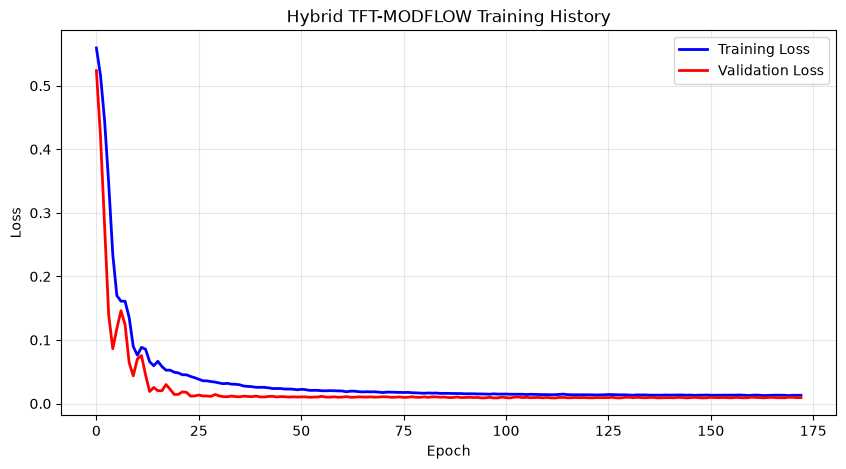


     EVALUATION

  Evaluating on validation set...
    Scored on 730 true validation-split rows (after excluding pre-val context windows)
  Evaluating on test set...
    Scored on 712 true test-split rows (after excluding pre-test context windows)

  Validation Metrics:
  ----------------------------------------
    RMSE: 0.0329
    MAE: 0.0244
    R2: 0.9897
    NSE: 0.9897

  Test Metrics:
  ----------------------------------------
    RMSE: 0.0273
    MAE: 0.0207
    R2: 0.9933
    NSE: 0.9933
  Results plot saved:  models/hybrid_tft\hybrid_results.png


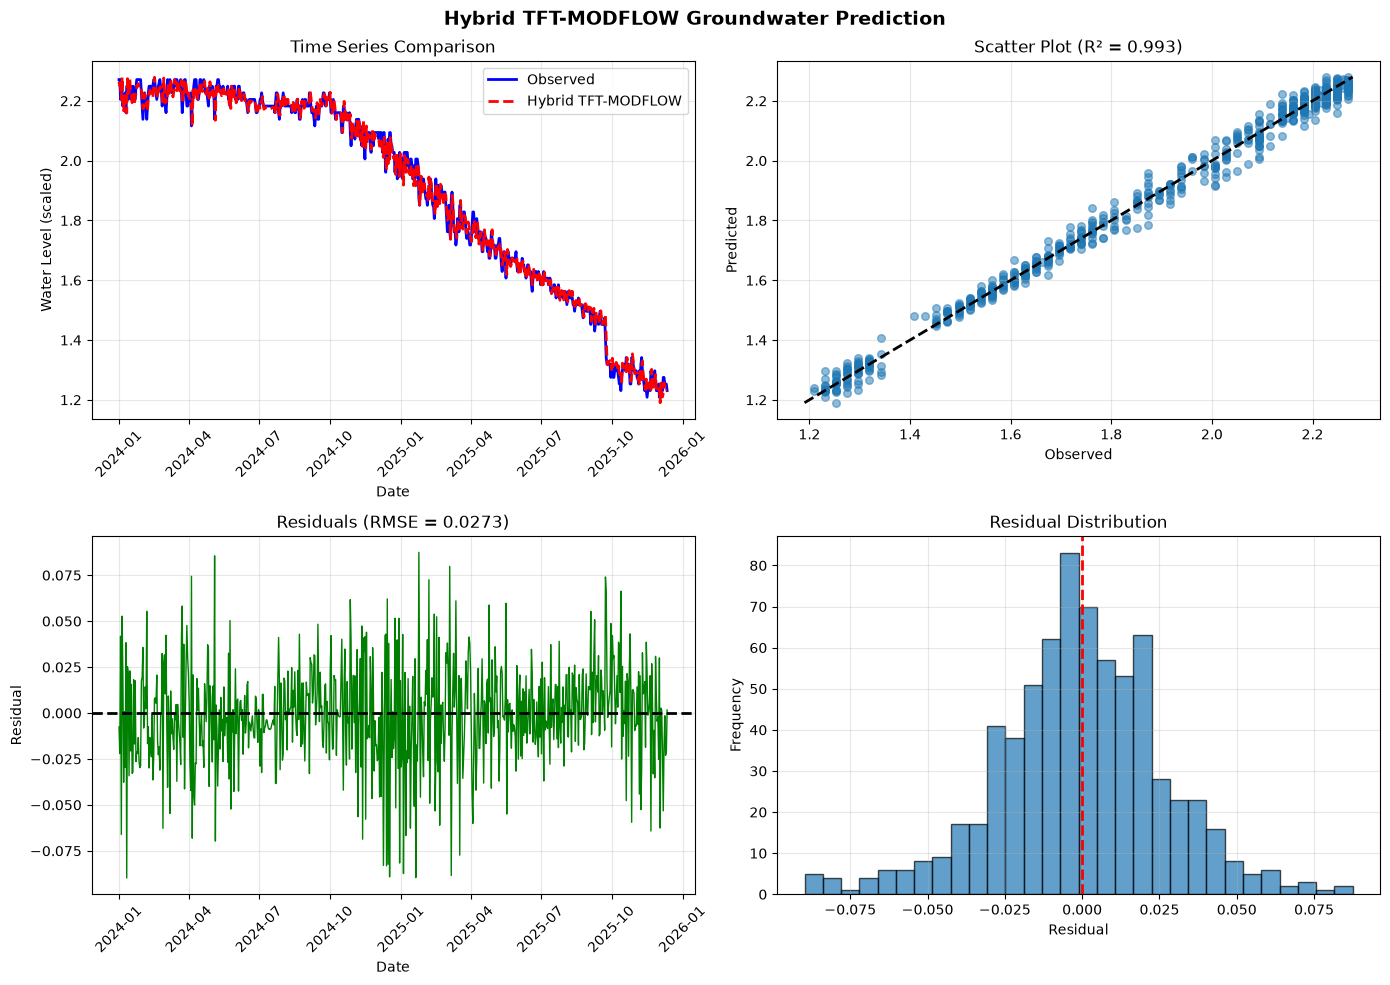

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



  Saving results...

  ✓ Results saved to:  models/hybrid_tft

  Extracting variable-selection / attention interpretation...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


    Saved: models/hybrid_tft\interpretation\interpretation_attention.png
    Saved: models/hybrid_tft\interpretation\interpretation_static_variables.png
    Saved: models/hybrid_tft\interpretation\interpretation_encoder_variables.png
    Saved: models/hybrid_tft\interpretation\interpretation_decoder_variables.png
    Saved: models/hybrid_tft\interpretation\variable_importance.csv

██████████████████████████████████████████████████████████████████████
   HYBRID TFT-MODFLOW PIPELINE COMPLETE!
██████████████████████████████████████████████████████████████████████


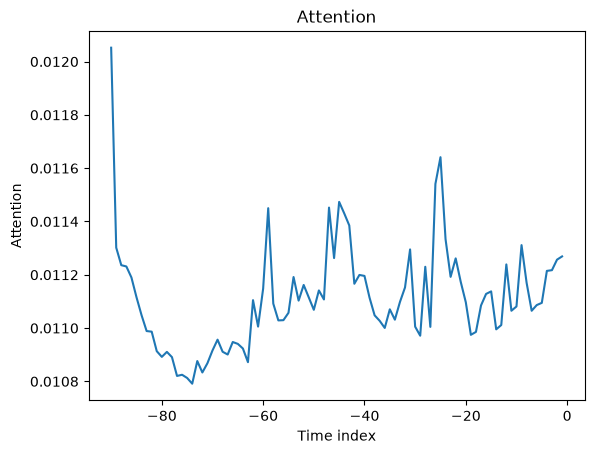

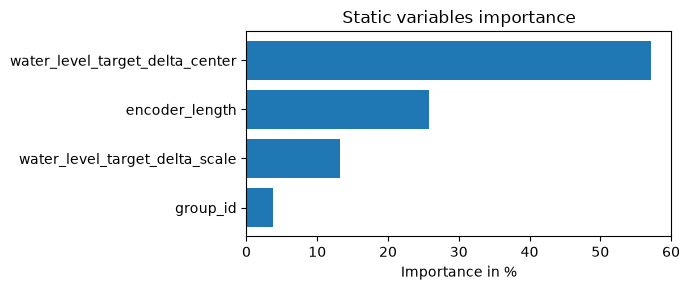

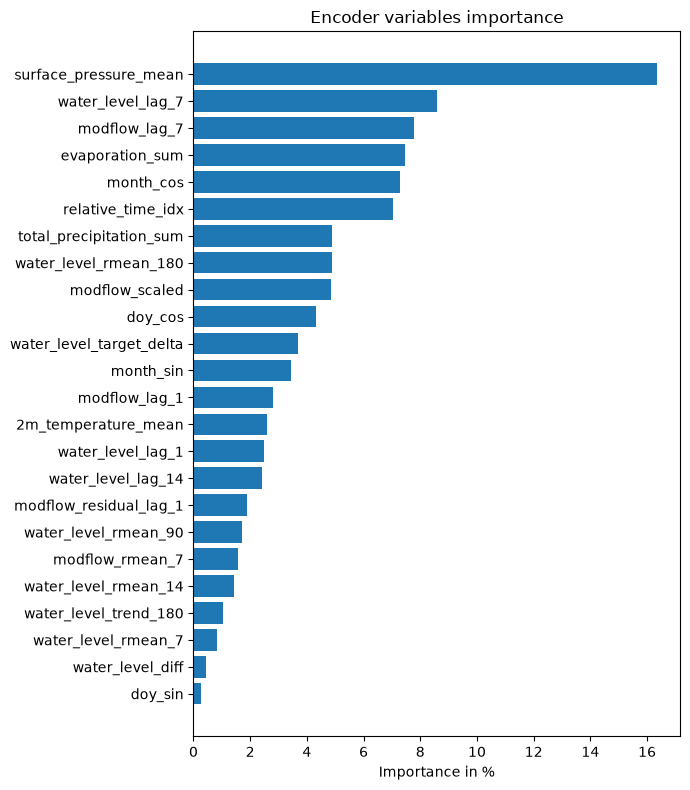

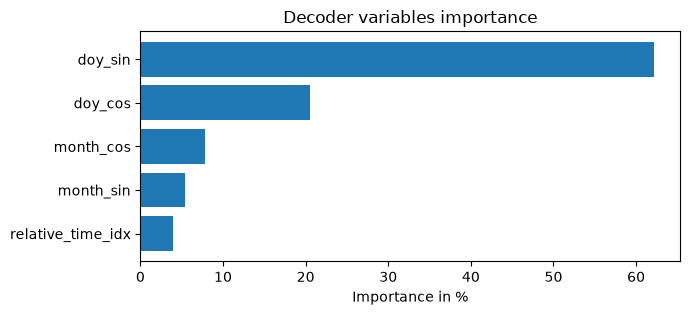

In [ ]:
predictions, actuals, metrics, model = run_hybrid_tft_modflow_pipeline(
    # Data paths (flat layout: data/ and models/ are siblings of this notebook)
    train_path='data/processed/train_scaled.csv',
    val_path='data/processed/val_scaled.csv',
    test_path='data/processed/test_scaled.csv',
    modflow_path='models/modflow_train_only/train_only_predictions.csv',
    scaler_path='data/processed/scalers.joblib',

    # Output
    model_dir='models/hybrid_tft_train_only',

    # Data columns
    target_col='water_level',
    date_col='date',
    modflow_pred_col='simulated_depth_ft',  # Column name in your MODFLOW CSV

    # Model parameters (same as the paper's reported Hybrid TFT-MODFLOW run,
    # with attention_head_size/dropout/weight_decay revised after the
    # original settings produced severely under-dispersed test predictions
    # -- predicted std ~0.09 vs. true std ~0.33 -- see the NOTE comment in
    # this pipeline's own __main__ block for the full diagnosis)
    max_encoder_length=90,
    max_prediction_length=1,
    hidden_size=128,
    attention_head_size=8,
    lstm_layers=3,
    dropout=0.2,
    learning_rate=0.0001,
    batch_size=616,
    max_epochs=300,
    patience=60,
    weight_decay=0.03,

    # Full MODFLOW-derived feature set (the "complete hybrid" configuration,
    # as opposed to the TFT-only ablation in run_ablation_no_modflow.py)
    include_modflow_features=True,
)


## Final results

In [15]:
if metrics:
    print("\n" + "=" * 50)
    print("HYBRID TFT-MODFLOW FINAL RESULTS")
    print("=" * 50)
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")



HYBRID TFT-MODFLOW FINAL RESULTS
  RMSE: 0.0269
  MAE: 0.0204
  R2: 0.9935
  NSE: 0.9935


## Results plot in feet (no retraining -- reuses the saved predictions)

The `## Run the pipeline` cell above plots and reports metrics in **scaled** units (`plot_results(..., is_scaled=True)`) -- e.g. an RMSE shown there like `0.0273` is scaled-unit RMSE, not feet, and is easy to misread as a worse number than it is. This cell reloads the already-saved `models/hybrid_tft/hybrid_predictions.csv` and the fitted target scaler, converts back to feet, and re-plots/re-reports metrics in feet -- no retraining, just reusing what the pipeline already saved to disk.

Test Metrics (feet, original units):
----------------------------------------
  RMSE: 0.0123
  MAE: 0.0093
  R2: 0.9933
  NSE: 0.9933
  Results plot saved:  models/hybrid_tft/hybrid_results_feet.png


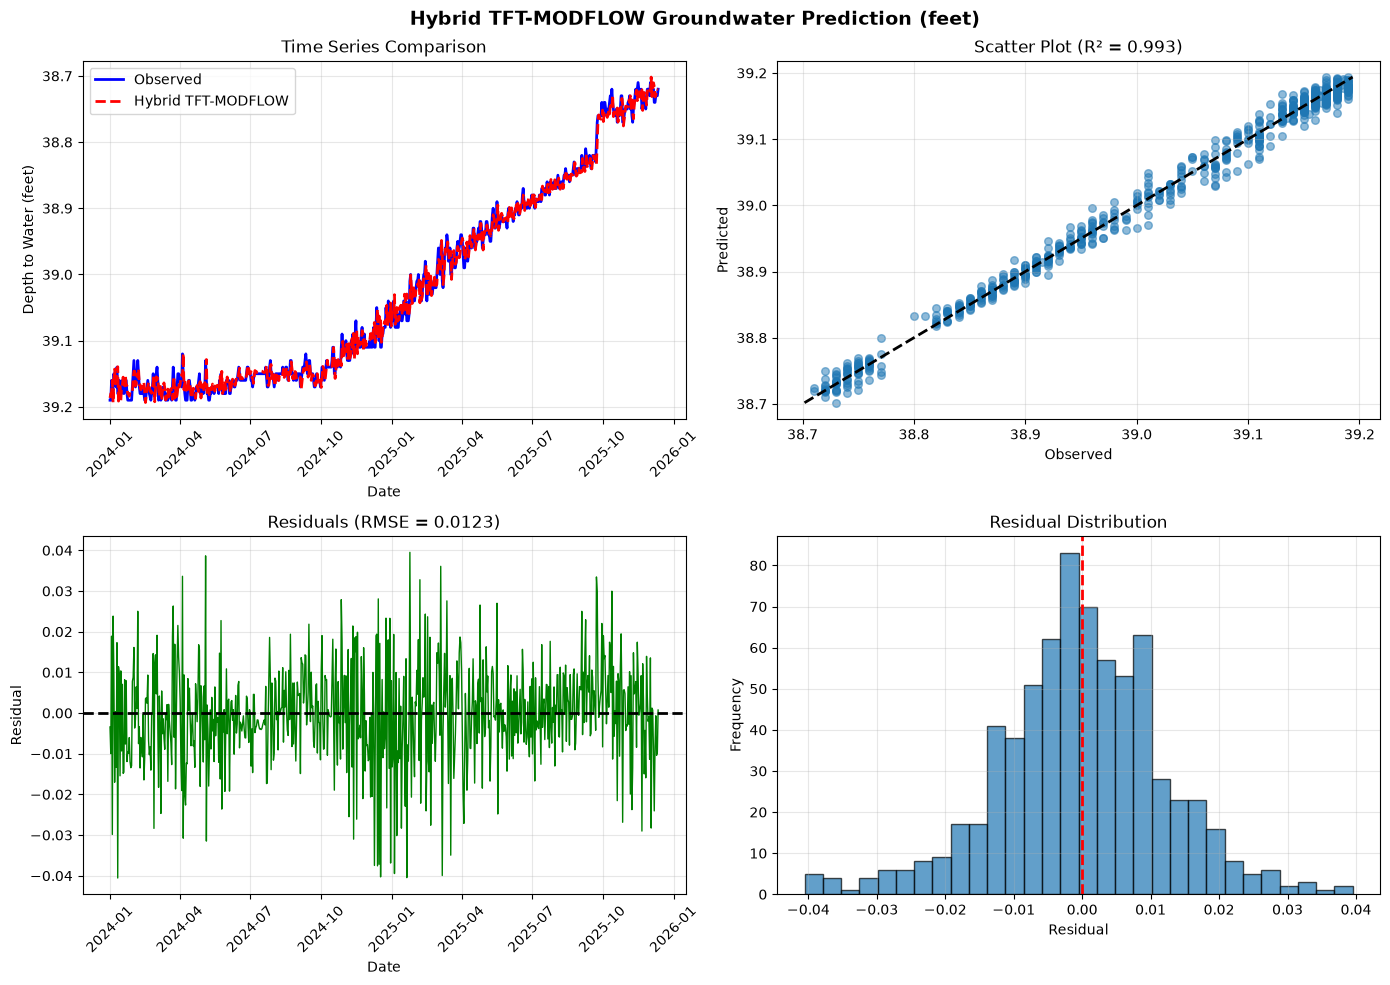

In [17]:
# =============================================================================
# FEET-UNIT RESULTS PLOT (no retraining -- reuses the saved hybrid_predictions.csv)
# =============================================================================
import pandas as pd
import numpy as np
import joblib

# Rebuild the same date <-> time_idx mapping the pipeline itself used
# (train+val+test concatenated, sorted by date, time_idx = row position --
# see HybridDataPreparator.prepare_for_tft), so the saved predictions'
# time_idx values resolve back to calendar dates for plotting.
_train_df = pd.read_csv('data/processed/train_scaled.csv', parse_dates=['date'])
_val_df = pd.read_csv('data/processed/val_scaled.csv', parse_dates=['date'])
_test_df = pd.read_csv('data/processed/test_scaled.csv', parse_dates=['date'])
_full_df = pd.concat([_train_df, _val_df, _test_df], ignore_index=True).sort_values('date').reset_index(drop=True)
_full_df['time_idx'] = np.arange(len(_full_df))

# Load the saved test-set predictions (still in SCALED units) and resolve dates
_preds_df = pd.read_csv('models/hybrid_tft/hybrid_predictions.csv')
_preds_df = _preds_df.merge(_full_df[['time_idx', 'date']], on='time_idx', how='left')

# Inverse-transform observed/predicted back to feet using the same scaler
# fit during data_spliting_and_scalling.py (train-split statistics only)
_scalers = joblib.load('data/processed/scalers.joblib')
_target_scaler = _scalers['target_scaler']

_observed_ft = _target_scaler.inverse_transform(_preds_df[['observed']].values).flatten()
_predicted_ft = _target_scaler.inverse_transform(_preds_df[['predicted']].values).flatten()

feet_metrics = calculate_metrics(_observed_ft, _predicted_ft)
print("Test Metrics (feet, original units):")
print("-" * 40)
for k, v in feet_metrics.items():
    print(f"  {k}: {v:.4f}")

plot_results(
    dates=_preds_df['date'].to_numpy(),
    observed=_observed_ft,
    predicted=_predicted_ft,
    metrics=feet_metrics,
    title='Hybrid TFT-MODFLOW Groundwater Prediction (feet)',
    save_path='models/hybrid_tft/hybrid_results_feet.png',
    is_scaled=False,
)


## Per-split metrics: train / val / test (no retraining)

Reuses the already-trained `model` from the `## Run the pipeline` cell above -- rebuilds the train/val/test dataloaders (same data config: paths, `target_col`, `date_col`, `modflow_pred_col`, `max_encoder_length`, `max_prediction_length`, `include_modflow_features`, must match the pipeline cell above) and runs a forward pass over each split, but the model itself is not retrained. `RMSE`/`MAE` are shown in both scaled and feet units (see the earlier feet-unit cell for why); `R2` is unit-invariant so only shown once.

In [1]:
# =============================================================================
# PER-SPLIT METRICS: TRAIN / VAL / TEST (no retraining -- reuses the already
# trained `model` from the pipeline cell above)
# =============================================================================
import pandas as pd
import joblib

# Must match the data config used in the "Run the pipeline" cell above --
# batch_size/dropout/etc. don't matter here since we are not rebuilding the
# model, only regenerating its input data.
_eval_config = HybridTFTConfig(
    train_path='data/processed/train_scaled.csv',
    val_path='data/processed/val_scaled.csv',
    test_path='data/processed/test_scaled.csv',
    modflow_path='models/modflow_enhanced/enhanced_predictions.csv',
    scaler_path='data/processed/scalers.joblib',
    model_dir='models/hybrid_tft',
    target_col='water_level',
    date_col='date',
    modflow_pred_col='simulated_depth_ft',
    max_encoder_length=90,
    max_prediction_length=1,
    batch_size=616,
    include_modflow_features=True,
)

_eval_data_prep = HybridDataPreparator(_eval_config)
_eval_data_prep.load_data()
_eval_data_prep.prepare_for_tft()
_training, _validation, _testing, _train_loader, _val_loader, _test_loader = _eval_data_prep.create_datasets()

_device = next(model.parameters()).device
_target_scaler = joblib.load('data/processed/scalers.joblib')['target_scaler']


def _evaluate_split(loader, split_name, target_col='water_level'):
    preds, actuals, indices = predict_tft(model, loader, _device)
    preds, actuals, indices = filter_by_split(preds, actuals, indices, _eval_data_prep.full_df, split_name)

    # Same quantile/shape handling as process_preds() inside
    # run_hybrid_tft_modflow_pipeline (that function is local to the
    # pipeline call and isn't importable here, so it's inlined).
    if len(preds.shape) == 3:
        preds = preds[:, 0, preds.shape[2] // 2]
    elif len(preds.shape) == 2 and preds.shape[1] >= 7:
        preds = preds[:, preds.shape[1] // 2]
    elif len(preds.shape) == 2:
        preds = preds[:, 0]
    if len(actuals.shape) == 2:
        actuals = actuals[:, 0]
    preds, actuals = preds.flatten(), actuals.flatten()

    # Delta-target reconstruction (see reconstruct_absolute_from_delta) --
    # preds/actuals above are still day-over-day deltas at this point.
    preds, actuals = reconstruct_absolute_from_delta(preds, actuals, indices, _eval_data_prep.full_df, target_col)

    scaled_metrics = calculate_metrics(actuals, preds)
    obs_ft = _target_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()
    pred_ft = _target_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    feet_metrics = calculate_metrics(obs_ft, pred_ft)

    return {
        'split': split_name,
        'n': len(actuals),
        'RMSE_scaled': scaled_metrics['RMSE'],
        'RMSE_ft': feet_metrics['RMSE'],
        'MAE_scaled': scaled_metrics['MAE'],
        'MAE_ft': feet_metrics['MAE'],
        'R2': scaled_metrics['R2'],
    }


_results = [
    _evaluate_split(_train_loader, 'train'),
    _evaluate_split(_val_loader, 'val'),
    _evaluate_split(_test_loader, 'test'),
]
metrics_by_split = pd.DataFrame(_results)
print(metrics_by_split.to_string(index=False))
metrics_by_split


NameError: name 'HybridTFTConfig' is not defined

## Equivalent-conditions comparison (reviewer comment: MODFLOW vs TFT vs Hybrid not comparable)

> *MODFLOW performance is calculated at monthly resolution over the full calibration period, whereas TFT and hybrid results are reported at daily resolution for the validation and test periods [...] All models should be evaluated over the same test period and temporal resolution [...] Bootstrap confidence intervals or statistical tests would help determine whether the relatively small improvement of the hybrid model over the standalone TFT is significant.*

This cell **does not retrain or re-run any model**. It reads only the saved predictions:

| Model | Saved file | Native resolution |
|---|---|---|
| Hybrid TFT-MODFLOW (this notebook: train-only MODFLOW prior) | `models/hybrid_tft_train_only/hybrid_predictions.csv` | daily |
| TFT (no MODFLOW) | `ablation_tests/results/tft_no_modflow/hybrid_predictions.csv` | daily |
| MODFLOW, calibrated on 2015-2021 only (the prior this hybrid uses) | `models/modflow_train_only/train_only_predictions.csv` | monthly |

The TFT-only comparator takes no MODFLOW input, so it is the same run for either hybrid. The MODFLOW file has no `split` column, so splits are assigned with the same date cut-offs as the data (train up to 2021-12-31, val up to 2023-12-31, test after that).

All models are scored on the **same test period (2024-01-01 to 2025-12-12)**, in feet, at two resolutions:

- **(a) Daily (712 days).** MODFLOW's monthly heads are linearly interpolated to daily, using the same interpolation the hybrid pipeline uses to build its MODFLOW feature.
- **(b) Monthly (24 months).** TFT, Hybrid and persistence daily predictions are averaged to calendar months. MODFLOW is used at its native monthly output. The observed series is the monthly mean of the daily observations.

Uncertainty and significance:

- **Paired moving-block bootstrap.** 5000 resamples, 30-day blocks (daily) and 3-month blocks (monthly). Every model is scored on the same resampled days. A block-length sensitivity check (7 to 90 days) is included.
- **Diebold-Mariano tests** for Hybrid vs TFT, with squared and absolute loss, Newey-West HAC variance and the Harvey-Leybourne-Newbold correction. They are run on all test days, on measured days only, and at monthly resolution.
- **Persistence** (`y[t-1]`) is included as the reference for a one-step-ahead forecast.

The cell is self-contained (its own imports) and takes about 30 s. Outputs are written to `results/equivalent_conditions_train_only/`.

C:\Users\naima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Test period: 2024-01-01 .. 2025-12-12 (712 days, 24 months); bootstrap: 5000 moving-block resamples (block = 30 d daily, 3 mo monthly)

=== (a) DAILY resolution, test period, feet ===
                           n  RMSE (ft)  MAE (ft)  Bias (ft)      NSE       r  RMSE (ft) 95% CI   MAE (ft) 95% CI            NSE 95% CI
MODFLOW (interp. daily)  712     0.6048    0.5411     0.5411 -15.1997 -0.9506  [0.4886, 0.6954]  [0.4350, 0.6432]  [-24.1539, -12.2317]
TFT (no MODFLOW)         712     0.0125    0.0094     0.0007   0.9931  0.9966  [0.0109, 0.0138]  [0.0082, 0.0105]      [0.9860, 0.9951]
Hybrid TFT-MODFLOW       712     0.0123    0.0093    -0.0003   0.9933  0.9966  [0.0107, 0.0137]  [0.0082, 0.0104]      [0.9861, 0.9953]
Persistence              712     0.0135    0.0096     0.0007   0.9919  0.9960  [0.0119, 0.0150]  [0.0082, 0.0108]      [0.9831, 0.9944]

=== (b) MONTHLY resolution, test period, feet (TFT/Hybrid/Persistence = monthly mean of daily predictions) ===
                        

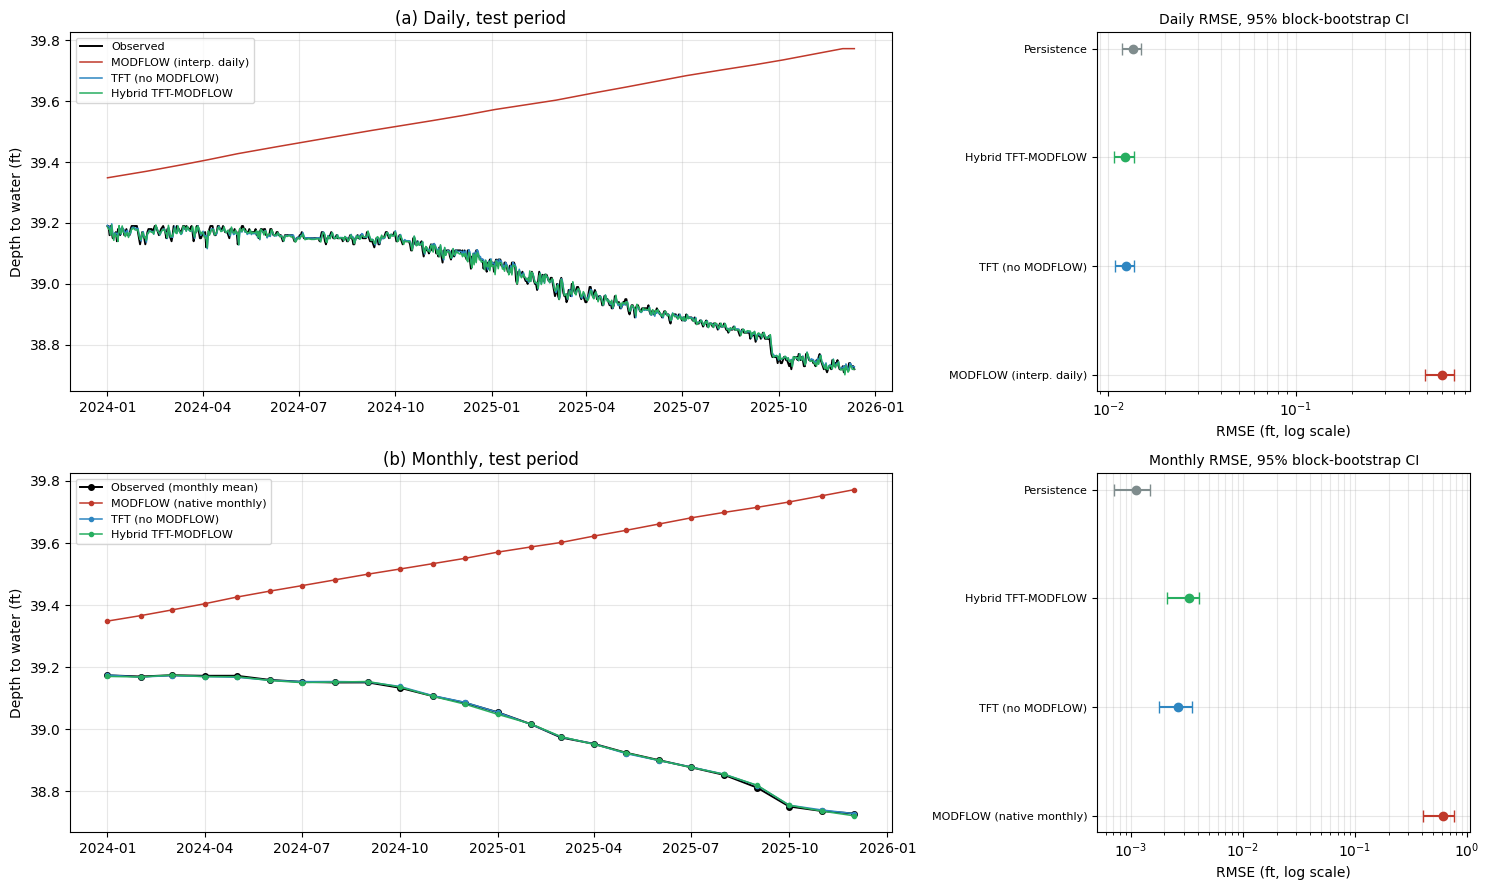


Saved tables and figure to results/equivalent_conditions_train_only/


In [3]:
# =============================================================================
# 6. EQUIVALENT-CONDITIONS COMPARISON (reviewer comment: Table 12 not comparable)
# =============================================================================
# Reads SAVED predictions only -- no model is retrained or re-run here.
#   Hybrid TFT-MODFLOW : models/hybrid_tft_train_only/hybrid_predictions.csv  (daily, scaled)
#   TFT (no MODFLOW)   : ablation_tests/results/tft_no_modflow/hybrid_predictions.csv (daily, scaled)
#   MODFLOW            : models/modflow_train_only/train_only_predictions.csv (monthly, feet;
#                        calibrated on 2015-2021 only = the prior this hybrid was trained with)
# Every model is scored on the SAME test period (2024-01-01 .. 2025-12-12) at
#   (a) daily resolution   -- MODFLOW linearly interpolated to daily (same interpolation
#                             the hybrid pipeline uses to build its MODFLOW feature)
#   (b) monthly resolution -- TFT / Hybrid daily predictions averaged to calendar months,
#                             MODFLOW at its native monthly output
# plus moving-block bootstrap 95% CIs and Diebold-Mariano tests for Hybrid vs TFT.
import os
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

EQ_OUT_DIR = "results/equivalent_conditions_train_only"
os.makedirs(EQ_OUT_DIR, exist_ok=True)

EQ_MODELS = {  # display name -> saved predictions CSV (time_idx, observed, predicted in scaled units)
    "TFT (no MODFLOW)": "ablation_tests/results/tft_no_modflow/hybrid_predictions.csv",
    "Hybrid TFT-MODFLOW": "models/hybrid_tft_train_only/hybrid_predictions.csv",
}
MODFLOW_CSV = "models/modflow_train_only/train_only_predictions.csv"
N_BOOT = 5000
BLOCK_DAYS = 30          # daily block length (errors are autocorrelated)
BLOCK_MONTHS = 3         # monthly block length
BLOCK_SENSITIVITY = [7, 14, 30, 60, 90]
RNG_SEED = 42

# --- observed daily series, same time_idx construction as the pipeline --------
_frames = []
for _s in ["train", "val", "test"]:
    _d = pd.read_csv(f"data/processed/{_s}_scaled.csv", parse_dates=["date"])
    _d["split"] = _s
    _frames.append(_d)
eq_full = pd.concat(_frames, ignore_index=True).sort_values("date").reset_index(drop=True)
eq_full["time_idx"] = np.arange(len(eq_full))
eq_scaler = joblib.load("data/processed/scalers.joblib")["target_scaler"]
eq_full["obs_ft"] = eq_scaler.inverse_transform(eq_full[["water_level"]]).ravel()
eq_full["is_interpolated"] = eq_full["is_interpolated"].astype(str).str.lower().eq("true")

test = eq_full.loc[eq_full["split"] == "test", ["time_idx", "date", "obs_ft", "is_interpolated"]].copy()

# --- learned models (daily) ----------------------------------------------------
for name, path in EQ_MODELS.items():
    p = pd.read_csv(path).drop_duplicates("time_idx").set_index("time_idx")
    ref = eq_full.set_index("time_idx").loc[p.index, "water_level"]
    assert np.nanmax(np.abs(p["observed"] - ref)) < 1e-6, f"{name}: time_idx misaligned"
    p[name] = eq_scaler.inverse_transform(p[["predicted"]]).ravel()
    test = test.merge(p[[name]], left_on="time_idx", right_index=True, how="left")

# --- MODFLOW: native monthly + linear interpolation to daily -----------------
mf = pd.read_csv(MODFLOW_CSV, parse_dates=["date"])
# this file has no split column (only in_calibration_window); use the same date cut-offs as the data split
mf["split"] = np.where(mf["date"] <= "2021-12-31", "train", np.where(mf["date"] <= "2023-12-31", "val", "test"))
mf_daily = (mf.set_index("date")["simulated_depth_ft"]
              .reindex(pd.date_range(mf["date"].min(), mf["date"].max(), freq="D"))
              .interpolate("linear", limit_direction="both"))
test["MODFLOW (interp. daily)"] = test["date"].map(mf_daily)
test["MODFLOW (interp. daily)"] = test["MODFLOW (interp. daily)"].ffill()  # 2025-12-02..12 after last stress period

# Persistence y[t-1] as a reference for a one-step-ahead forecast
y_by_idx = eq_full.set_index("time_idx")["obs_ft"]
test["Persistence"] = y_by_idx.reindex(test["time_idx"] - 1).to_numpy()

DAILY_MODELS = ["MODFLOW (interp. daily)", "TFT (no MODFLOW)", "Hybrid TFT-MODFLOW", "Persistence"]
assert test[DAILY_MODELS].notna().all().all(), "every model must cover every test day"

# --- monthly aggregation (calendar-month means over the same test days) ---------
monthly = test.set_index("date")[["obs_ft", "TFT (no MODFLOW)", "Hybrid TFT-MODFLOW", "Persistence"]].resample("MS").mean()
monthly["MODFLOW (native monthly)"] = mf.set_index("date")["simulated_depth_ft"].reindex(monthly.index)
MONTHLY_MODELS = ["MODFLOW (native monthly)", "TFT (no MODFLOW)", "Hybrid TFT-MODFLOW", "Persistence"]
assert monthly[MONTHLY_MODELS].notna().all().all()


def eq_metrics(obs, pred):
    err = pred - obs
    return {
        "n": len(obs),
        "RMSE (ft)": np.sqrt(np.mean(err ** 2)),
        "MAE (ft)": np.mean(np.abs(err)),
        "Bias (ft)": np.mean(err),
        "NSE": 1 - np.sum(err ** 2) / np.sum((obs - obs.mean()) ** 2),
        "r": np.corrcoef(obs, pred)[0, 1],
    }


def block_indices(n, block, rng):
    starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return np.concatenate([np.arange(s, s + block) for s in starts])[:n]


def bootstrap_table(df, models, block, n_boot=N_BOOT, seed=RNG_SEED):
    """Paired moving-block bootstrap: every model is scored on the SAME resampled days."""
    rng = np.random.default_rng(seed)
    obs = df["obs_ft"].to_numpy()
    P = {m: df[m].to_numpy() for m in models}
    draws = {m: {k: np.empty(n_boot) for k in ["RMSE (ft)", "MAE (ft)", "NSE"]} for m in models}
    for b in range(n_boot):
        idx = block_indices(len(obs), block, rng)
        o = obs[idx]
        sst = np.sum((o - o.mean()) ** 2)
        for m in models:
            e = P[m][idx] - o
            draws[m]["RMSE (ft)"][b] = np.sqrt(np.mean(e ** 2))
            draws[m]["MAE (ft)"][b] = np.mean(np.abs(e))
            draws[m]["NSE"][b] = 1 - np.sum(e ** 2) / sst
    return draws


def summarize(df, models, block, label):
    point = pd.DataFrame({m: eq_metrics(df["obs_ft"].to_numpy(), df[m].to_numpy()) for m in models}).T
    draws = bootstrap_table(df, models, block)
    for k in ["RMSE (ft)", "MAE (ft)", "NSE"]:
        lo = [np.percentile(draws[m][k], 2.5) for m in models]
        hi = [np.percentile(draws[m][k], 97.5) for m in models]
        point[f"{k} 95% CI"] = [f"[{a:.4f}, {b:.4f}]" for a, b in zip(lo, hi)]
    point["n"] = point["n"].astype(int)
    point.insert(0, "resolution", label)
    return point, draws


def paired_difference(draws, point, a, b, label):
    """RMSE/MAE of model a minus model b; negative = a better. Percentile CI, shifted-null p-value."""
    rows = []
    for k in ["RMSE (ft)", "MAE (ft)"]:
        d = draws[a][k] - draws[b][k]
        obs_d = point.loc[a, k] - point.loc[b, k]
        lo, hi = np.percentile(d, [2.5, 97.5])
        p = np.mean(np.abs(d - d.mean()) >= abs(obs_d))
        rows.append({"resolution": label, "comparison": f"{a} - {b}", "metric": k,
                     "difference": obs_d, "relative (%)": 100 * obs_d / point.loc[b, k],
                     "95% CI low": lo, "95% CI high": hi, "bootstrap p": p,
                     "CI excludes 0": bool(lo > 0 or hi < 0)})
    return rows


def diebold_mariano(e_a, e_b, loss="squared", h=1):
    """DM test with Newey-West HAC variance and Harvey-Leybourne-Newbold correction."""
    d = e_a ** 2 - e_b ** 2 if loss == "squared" else np.abs(e_a) - np.abs(e_b)
    n = len(d)
    lag = max(int(np.floor(4 * (n / 100) ** (2 / 9))), h - 1)
    x = d - d.mean()
    lrv = np.mean(x * x) + sum(2 * (1 - k / (lag + 1)) * np.mean(x[k:] * x[:-k]) for k in range(1, lag + 1))
    dm = d.mean() / math.sqrt(lrv / n)
    dm_hln = dm * math.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return {"loss": loss, "n": n, "HAC lag": lag, "DM (HLN)": dm_hln,
            "p two-sided": 2 * stats.t.sf(abs(dm_hln), df=n - 1),
            "p one-sided (A better)": stats.t.cdf(dm_hln, df=n - 1)}


# --- (a) daily, (b) monthly tables ----------------------------------------------------
daily_tbl, daily_draws = summarize(test, DAILY_MODELS, BLOCK_DAYS, "daily")
monthly_tbl, monthly_draws = summarize(monthly.reset_index(), MONTHLY_MODELS, BLOCK_MONTHS, "monthly")
eq_table = pd.concat([daily_tbl, monthly_tbl]).rename_axis("model").reset_index()

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 20)
print(f"Test period: {test['date'].min().date()} .. {test['date'].max().date()} "
      f"({len(test)} days, {len(monthly)} months); bootstrap: {N_BOOT} moving-block resamples "
      f"(block = {BLOCK_DAYS} d daily, {BLOCK_MONTHS} mo monthly)\n")
print("=== (a) DAILY resolution, test period, feet ===")
print(daily_tbl.drop(columns="resolution").to_string())
print("\n=== (b) MONTHLY resolution, test period, feet (TFT/Hybrid/Persistence = monthly mean of daily predictions) ===")
print(monthly_tbl.drop(columns="resolution").to_string())

# --- MODFLOW as it was reported before (all splits, native monthly) for reference -------------
mf_by_split = pd.DataFrame({s: eq_metrics(g["observed_depth_ft"].to_numpy(), g["simulated_depth_ft"].to_numpy())
                            for s, g in list(mf.groupby("split")) + [("all periods", mf)]}).T
mf_by_split["n"] = mf_by_split["n"].astype(int)
print("\n=== MODFLOW native monthly, by split (train = calibration period) ===")
print(mf_by_split.loc[["train", "val", "test", "all periods"]].to_string())

# --- Hybrid vs TFT significance -------------------------------------------------------------
diff_rows = (paired_difference(daily_draws, daily_tbl, "Hybrid TFT-MODFLOW", "TFT (no MODFLOW)", "daily")
             + paired_difference(daily_draws, daily_tbl, "Hybrid TFT-MODFLOW", "Persistence", "daily")
             + paired_difference(monthly_draws, monthly_tbl, "Hybrid TFT-MODFLOW", "TFT (no MODFLOW)", "monthly"))
diff_tbl = pd.DataFrame(diff_rows)
print("\n=== Paired block-bootstrap differences (negative = Hybrid better) ===")
print(diff_tbl.to_string(index=False))

sens = []
for bl in BLOCK_SENSITIVITY:
    dr = bootstrap_table(test, ["TFT (no MODFLOW)", "Hybrid TFT-MODFLOW"], bl, n_boot=2000)
    d = dr["Hybrid TFT-MODFLOW"]["RMSE (ft)"] - dr["TFT (no MODFLOW)"]["RMSE (ft)"]
    obs_d = daily_tbl.loc["Hybrid TFT-MODFLOW", "RMSE (ft)"] - daily_tbl.loc["TFT (no MODFLOW)", "RMSE (ft)"]
    sens.append({"block (days)": bl, "RMSE diff 95% CI low": np.percentile(d, 2.5),
                 "RMSE diff 95% CI high": np.percentile(d, 97.5),
                 "bootstrap p": np.mean(np.abs(d - d.mean()) >= abs(obs_d))})
sens_tbl = pd.DataFrame(sens)
print("\n=== Sensitivity of the daily Hybrid - TFT RMSE CI to bootstrap block length ===")
print(sens_tbl.to_string(index=False))

dm_rows = []
for label, df in [("daily, all test days", test),
                          ("daily, measured days only", test[~test["is_interpolated"]]),
                          ("monthly", monthly)]:
    e_h = (df["Hybrid TFT-MODFLOW"] - df["obs_ft"]).to_numpy()
    e_t = (df["TFT (no MODFLOW)"] - df["obs_ft"]).to_numpy()
    for loss in ["squared", "absolute"]:
        dm_rows.append({"subset": label, "A": "Hybrid TFT-MODFLOW", "B": "TFT (no MODFLOW)",
                        **diebold_mariano(e_h, e_t, loss)})
dm_tbl = pd.DataFrame(dm_rows)
print("\n=== Diebold-Mariano tests, Hybrid (A) vs TFT (B); DM < 0 = Hybrid more accurate ===")
print(dm_tbl.to_string(index=False))

# --- save ----------------------------------------------------------------------------------
eq_table.to_csv(f"{EQ_OUT_DIR}/equivalent_conditions_metrics.csv", index=False)
mf_by_split.to_csv(f"{EQ_OUT_DIR}/modflow_metrics_by_split.csv", index_label="split")
diff_tbl.to_csv(f"{EQ_OUT_DIR}/bootstrap_differences.csv", index=False)
sens_tbl.to_csv(f"{EQ_OUT_DIR}/bootstrap_block_sensitivity.csv", index=False)
dm_tbl.to_csv(f"{EQ_OUT_DIR}/dm_tests_hybrid_vs_tft.csv", index=False)
test.to_csv(f"{EQ_OUT_DIR}/aligned_daily_test_predictions.csv", index=False)
monthly.to_csv(f"{EQ_OUT_DIR}/aligned_monthly_test_predictions.csv", index_label="date")

# --- figure --------------------------------------------------------------------------------
colors = {"MODFLOW (interp. daily)": "#c0392b", "MODFLOW (native monthly)": "#c0392b",
          "TFT (no MODFLOW)": "#2e86c1", "Hybrid TFT-MODFLOW": "#27ae60", "Persistence": "#7f8c8d"}
fig, axes = plt.subplots(2, 2, figsize=(15, 9), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0, 0]
ax.plot(test["date"], test["obs_ft"], "k-", lw=1.4, label="Observed")
for m in ["MODFLOW (interp. daily)", "TFT (no MODFLOW)", "Hybrid TFT-MODFLOW"]:
    ax.plot(test["date"], test[m], lw=1.1, color=colors[m], label=m)
ax.set_title("(a) Daily, test period"); ax.set_ylabel("Depth to water (ft)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 0]
ax.plot(monthly.index, monthly["obs_ft"], "ko-", lw=1.4, ms=4, label="Observed (monthly mean)")
for m in ["MODFLOW (native monthly)", "TFT (no MODFLOW)", "Hybrid TFT-MODFLOW"]:
    ax.plot(monthly.index, monthly[m], "o-", ms=3, lw=1.1, color=colors[m], label=m)
ax.set_title("(b) Monthly, test period"); ax.set_ylabel("Depth to water (ft)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
for ax, tbl, draws, models, title in [(axes[0, 1], daily_tbl, daily_draws, DAILY_MODELS, "Daily RMSE, 95% block-bootstrap CI"),
                                      (axes[1, 1], monthly_tbl, monthly_draws, MONTHLY_MODELS, "Monthly RMSE, 95% block-bootstrap CI")]:
    for i, m in enumerate(models):
        lo, hi = np.percentile(draws[m]["RMSE (ft)"], [2.5, 97.5])
        ax.errorbar(tbl.loc[m, "RMSE (ft)"], i, xerr=[[tbl.loc[m, "RMSE (ft)"] - lo], [hi - tbl.loc[m, "RMSE (ft)"]]],
                    fmt="o", color=colors[m], capsize=4)
    ax.set_yticks(range(len(models))); ax.set_yticklabels(models, fontsize=8); ax.set_xscale("log")
    ax.set_xlabel("RMSE (ft, log scale)"); ax.set_title(title, fontsize=10); ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(f"{EQ_OUT_DIR}/equivalent_conditions_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"\nSaved tables and figure to {EQ_OUT_DIR}/")

### Results and proposed response to the reviewer

**1. Same period, same resolution.** On the common test period (2024-01-01 to 2025-12-12):

| Model | Daily RMSE (ft) [95% CI] | Daily NSE | Monthly RMSE (ft) [95% CI] | Monthly NSE |
|---|---|---|---|---|
| MODFLOW, train-only calibration (interpolated daily / native monthly) | 0.605 [0.489, 0.695] | -15.2 | 0.612 [0.405, 0.759] | -14.7 |
| TFT (no MODFLOW) | 0.0125 [0.0109, 0.0138] | 0.993 | 0.0026 [0.0018, 0.0035] | 0.9997 |
| Hybrid TFT-MODFLOW | 0.0123 [0.0107, 0.0137] | 0.993 | 0.0033 [0.0021, 0.0040] | 0.9995 |
| Persistence `y[t-1]` | 0.0135 [0.0119, 0.0150] | 0.992 | 0.0011 [0.0007, 0.0015] | 0.9999 |

MODFLOW scores NSE = 0.83 over its calibration period (2015-2021) and 0.70 over the full record. On the independent test period it scores NSE = -14.7 (RMSE 0.61 ft, bias +0.55 ft, r = -0.96). Calibrated only on the 2015-2021 decline, it keeps simulating a deepening water table, while the observed depth to water decreased by about 0.45 ft during 2024-2025. The favourable MODFLOW statistic previously reported came from the calibration period. It does not carry over to the test period.

**2. Why the gap is so large.** TFT and Hybrid are one-day-ahead forecasts that use observed water levels up to *t-1* as inputs. MODFLOW is an open-loop simulation driven only by forcings and calibrated parameters, with no updating from observations. The comparison therefore contrasts forecast skill with simulation skill. Persistence alone reaches RMSE = 0.0135 ft. At monthly resolution, averaging one-step-ahead forecasts removes the day-to-day noise, so persistence scores best. Monthly scores of daily forecasters therefore measure smoothing, not monthly predictive skill, and are reported only as the complementary comparison the reviewer requested.

**3. Is the Hybrid better than the standalone TFT?** No, not significantly.

- **Daily RMSE:** 0.01233 vs 0.01247 ft, a 1.1% reduction. The paired block-bootstrap 95% CI of the difference, [-0.0005, +0.0002] ft, includes zero (p = 0.45). The p-value stays between 0.31 and 0.43 for block lengths of 7 to 90 days.
- **Diebold-Mariano, all days:** not significant with squared loss (p = 0.41) or absolute loss (p = 0.77).
- **Diebold-Mariano, measured days only:** not significant with squared loss (p = 0.31) or absolute loss (p = 0.55).
- **Monthly:** the Hybrid is slightly worse, but not significantly (RMSE +27%, p = 0.12; DM p = 0.17).

Both learned models beat persistence at daily resolution (Hybrid vs persistence RMSE -8.8%, bootstrap p < 0.001). The difference between the Hybrid and the standalone TFT is within sampling uncertainty. The manuscript should not claim an accuracy gain from adding MODFLOW. The case for the MODFLOW input rests on physical consistency and interpretability (ablation and VSN sections), and should be stated that way.

**Proposed manuscript change:** replace Table 12 with the equivalent-conditions table above (`results/equivalent_conditions_train_only/equivalent_conditions_metrics.csv`), add the bootstrap/DM table (`bootstrap_differences.csv`, `dm_tests_hybrid_vs_tft.csv`) and the figure (`equivalent_conditions_comparison.png`), and state explicitly that MODFLOW is evaluated as an open-loop simulation and the TFT models as one-step-ahead forecasts.